1. **ANALYSE DU DATASET**

ANALYSE DU DATASET PROFESSEUR

✅ Dataset trouvé : /kaggle/input/datasets/yyazidd/masked-celebahq-cropped-images

📁 STRUCTURE DU DATASET
------------------------------------------------------------
📁 facesDataset/ (30571 items)
  📄 0000000.png (0.02 MB)
  📄 0000001.png (0.02 MB)
  📄 0000002.png (0.02 MB)
  📄 0000003.png (0.03 MB)
  📄 0000004.png (0.03 MB)
  📄 0000005.png (0.02 MB)
  📄 0000006.png (0.03 MB)
  📄 0000007.png (0.02 MB)
  📄 0000008.png (0.02 MB)
  📄 0000009.png (0.03 MB)
  📄 0000010.png (0.02 MB)
  📄 0000011.png (0.02 MB)
  📄 0000012.png (0.03 MB)
  📄 0000013.png (0.03 MB)
  📄 0000014.png (0.03 MB)
  📄 0000015.png (0.03 MB)
  📄 0000016.png (0.02 MB)
  📄 0000017.png (0.03 MB)
  📄 0000018.png (0.02 MB)
  📄 0000019.png (0.03 MB)
  ... et 30551 autres items
📁 facesDataset_masked/ (24678 items)
  📄 0000000_surgical_green.png (0.03 MB)
  📄 0000001_inpaint.png (0.03 MB)
  📄 0000002_empty.png (0.02 MB)
  📄 0000003_surgical_green.png (0.03 MB)
  📄 0000004_cloth.png (0.03 MB)
  📄 0000

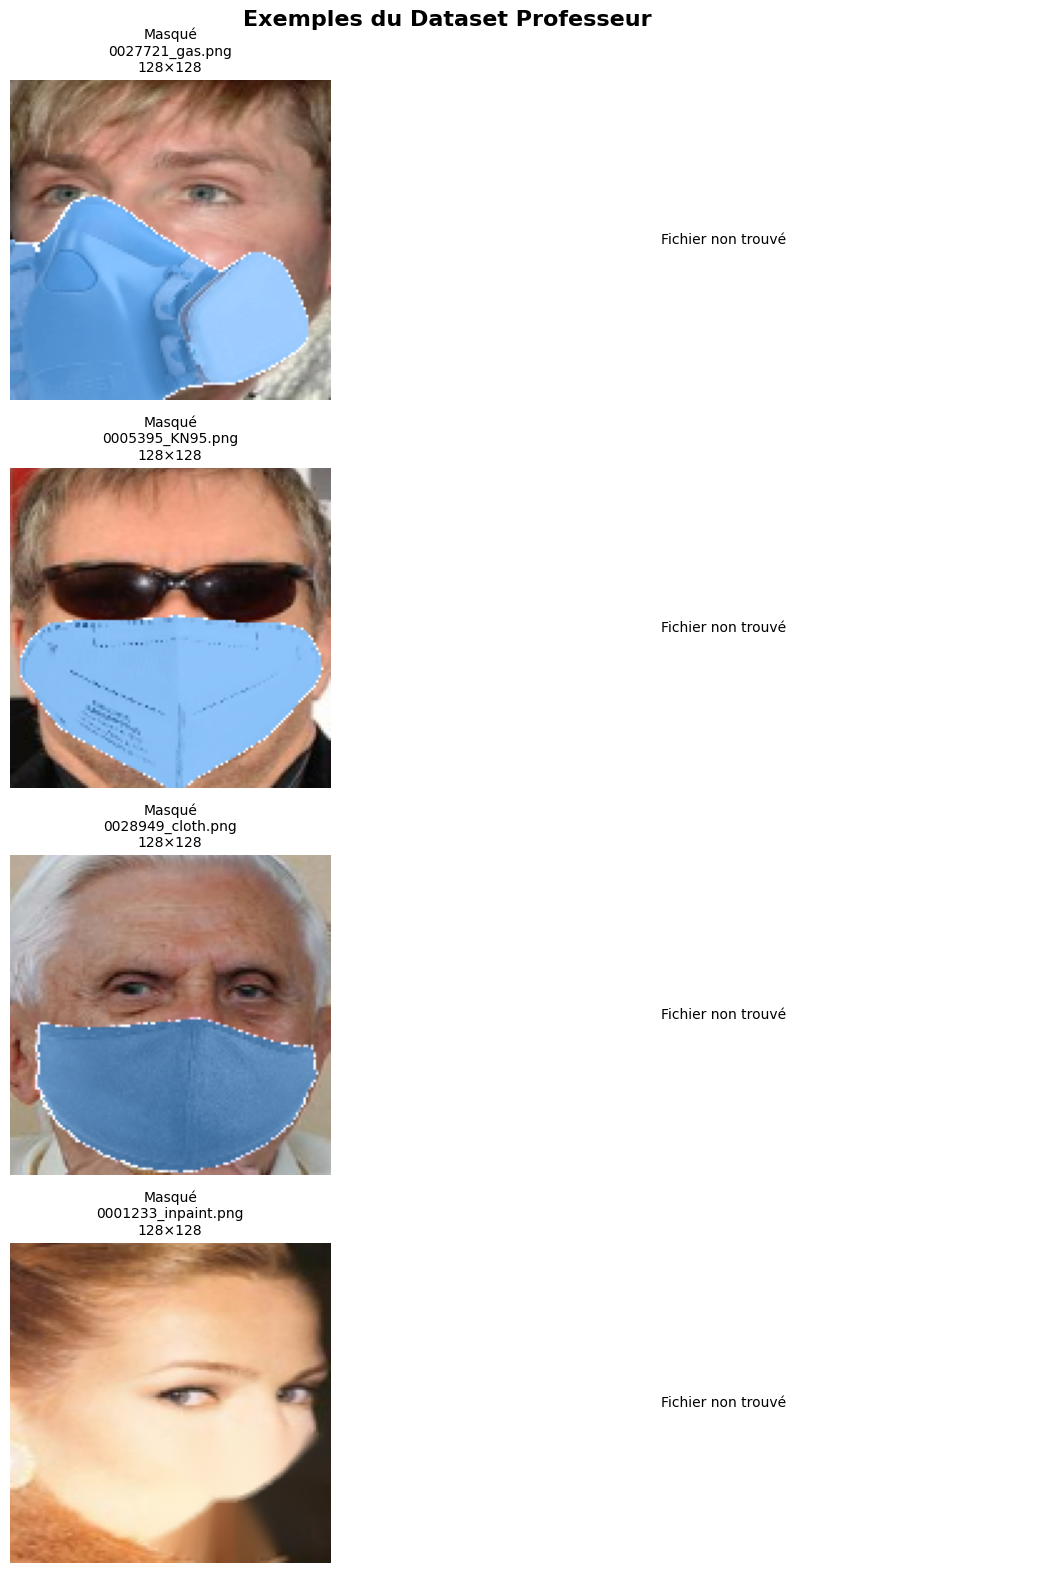

✅ Visualisation sauvegardée et affichée


📊 RECOMMANDATIONS

✅ Dataset analysé : 24678 paires détectées

⚠️  CORRECT mais peut être amélioré
   → Suffisant pour un premier entraînement
   → Possibilité d'ajouter CelebA si résultats < 27 PSNR

✅ DÉCISION : Commencer avec ce dataset
              Préparer CelebA en parallèle (optionnel)


📐 VÉRIFICATION DES DIMENSIONS REQUISES
------------------------------------------------------------
Dimensions actuelles :
  Masqué     : 128×128
  Non-masqué : 128×128

Dimensions requises :
  Input  : 32×32
  Target : 128×128

⚠️  RESIZE NÉCESSAIRE
   → Créer script de preprocessing
   → Voir 'preprocessing_script.py'

ANALYSE TERMINÉE

📝 Prochaines étapes :
1. ✅ Dataset analysé
2. Lire JDSR-GAN + Cheng EFBPGAN (2h)
3. Télécharger codes GitHub
4. Créer DataLoader PyTorch
5. Commencer l'implémentation !

💡 TIP KAGGLE :
   Activez GPU : Settings → Accelerator → GPU P100
   Cela sera nécessaire pour l'entraînement !


In [1]:
"""
SCRIPT D'ANALYSE DU DATASET - VERSION KAGGLE
À exécuter dans un notebook Kaggle
"""
import os
from pathlib import Path
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

print("="*60)
print("ANALYSE DU DATASET PROFESSEUR")
print("="*60)

# ============================================
# CONFIGURATION KAGGLE
# ============================================
DATASET_PATH = "/kaggle/input/datasets/yyazidd/masked-celebahq-cropped-images"

if not os.path.exists(DATASET_PATH):
    print(f"\n❌ Dataset introuvable : {DATASET_PATH}")
    print("\n💡 Vérifiez que vous avez bien ajouté le dataset dans votre notebook")
    print("   Settings → Add Data → Search 'masked celebahq cropped'")
    exit(1)

print(f"\n✅ Dataset trouvé : {DATASET_PATH}\n")

# ============================================
# 1. STRUCTURE DU DATASET
# ============================================
print("📁 STRUCTURE DU DATASET")
print("-" * 60)

def analyze_structure(path, level=0, max_level=2):
    """Analyse récursive de la structure"""
    if level > max_level:
        return
    
    try:
        items = sorted(os.listdir(path))
        for item in items[:20]:  # Afficher plus d'items
            item_path = os.path.join(path, item)
            indent = "  " * level
            
            if os.path.isdir(item_path):
                try:
                    num_files = len(os.listdir(item_path))
                    print(f"{indent}📁 {item}/ ({num_files} items)")
                    if level < max_level:
                        analyze_structure(item_path, level + 1, max_level)
                except:
                    print(f"{indent}📁 {item}/ (inaccessible)")
            else:
                size_mb = os.path.getsize(item_path) / (1024 * 1024)
                print(f"{indent}📄 {item} ({size_mb:.2f} MB)")
        
        if len(items) > 20:
            print(f"{indent}... et {len(items) - 20} autres items")
    except Exception as e:
        print(f"Erreur : {e}")

analyze_structure(DATASET_PATH)

# ============================================
# 2. TROUVER LES DOSSIERS IMAGES
# ============================================
print("\n\n🔍 RECHERCHE DES DOSSIERS D'IMAGES")
print("-" * 60)

def find_image_dirs(root_path):
    """Trouve tous les dossiers contenant des images"""
    image_dirs = {}
    
    for dirpath, dirnames, filenames in os.walk(root_path):
        # Compter les images dans ce dossier
        images = [f for f in filenames 
                 if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        if images:
            rel_path = os.path.relpath(dirpath, root_path)
            image_dirs[rel_path] = len(images)
    
    return image_dirs

image_dirs = find_image_dirs(DATASET_PATH)

print("\nDossiers trouvés :")
for dir_name, count in sorted(image_dirs.items(), key=lambda x: x[1], reverse=True):
    print(f"  {dir_name:50s} : {count:6d} images")

# ============================================
# 3. IDENTIFIER MASQUÉ vs NON-MASQUÉ
# ============================================
print("\n\n🎭 IDENTIFICATION MASQUÉ / NON-MASQUÉ")
print("-" * 60)

masked_dir = None
unmasked_dir = None

# Chercher avec différents patterns possibles
for dir_name in image_dirs.keys():
    dir_lower = dir_name.lower()
    
    # Patterns pour masqué
    if any(keyword in dir_lower for keyword in ['mask', 'masked', 'with_mask', 'withmask']):
        if not any(kw in dir_lower for kw in ['unmask', 'unmasked', 'without', 'clean']):
            masked_dir = dir_name
            print(f"✅ Trouvé MASQUÉ : {dir_name}")
    
    # Patterns pour non-masqué  
    if any(keyword in dir_lower for keyword in ['unmask', 'unmasked', 'without', 'clean', 'original', 'no_mask', 'nomask']):
        unmasked_dir = dir_name
        print(f"✅ Trouvé NON-MASQUÉ : {dir_name}")

# Si pas trouvé automatiquement, essayer des chemins probables
if not masked_dir or not unmasked_dir:
    print("\n⚠️  Détection automatique échouée, test des chemins standards...")
    
    possible_paths = [
        ('facesDataset_masked', 'facesDataset'),
        ('masked', 'unmasked'),
        ('with_mask', 'without_mask'),
        ('.', '.')  # Parfois les images sont directement dans le dossier root
    ]
    
    for mask_path, unmask_path in possible_paths:
        test_masked = os.path.join(DATASET_PATH, mask_path) if mask_path != '.' else DATASET_PATH
        test_unmasked = os.path.join(DATASET_PATH, unmask_path) if unmask_path != '.' else DATASET_PATH
        
        if os.path.exists(test_masked) and os.path.exists(test_unmasked):
            masked_files = [f for f in os.listdir(test_masked) if f.endswith(('.png', '.jpg'))]
            unmasked_files = [f for f in os.listdir(test_unmasked) if f.endswith(('.png', '.jpg'))]
            
            if masked_files and unmasked_files:
                masked_dir = mask_path
                unmasked_dir = unmask_path
                print(f"✅ Détecté : {mask_path} / {unmask_path}")
                break

if masked_dir:
    print(f"\n✅ Dossier MASQUÉ     : {masked_dir}")
    print(f"   → {image_dirs.get(masked_dir, 0)} images")
else:
    print(f"\n❌ Dossier MASQUÉ non trouvé")

if unmasked_dir:
    print(f"\n✅ Dossier NON-MASQUÉ : {unmasked_dir}")
    print(f"   → {image_dirs.get(unmasked_dir, 0)} images")
else:
    print(f"\n❌ Dossier NON-MASQUÉ non trouvé")

if not masked_dir or not unmasked_dir:
    print("\n⚠️  ATTENTION : Vérifiez manuellement la structure")
    print("Listez les dossiers disponibles ci-dessus")

# ============================================
# 4. ANALYSE DES DIMENSIONS
# ============================================
print("\n\n📐 ANALYSE DES DIMENSIONS")
print("-" * 60)

def analyze_dimensions(dir_path, sample_size=100):
    """Analyse les dimensions d'un échantillon"""
    if not dir_path:
        return None
        
    full_path = os.path.join(DATASET_PATH, dir_path) if dir_path != '.' else DATASET_PATH
    
    if not os.path.exists(full_path):
        return None
    
    images = [f for f in os.listdir(full_path) 
             if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    
    if not images:
        return None
    
    # Échantillonner
    sample = np.random.choice(images, min(sample_size, len(images)), replace=False)
    
    dimensions = []
    for img_name in sample:
        try:
            img_path = os.path.join(full_path, img_name)
            with Image.open(img_path) as img:
                dimensions.append(img.size)  # (width, height)
        except Exception as e:
            continue
    
    return dimensions

dims_masked = None
dims_unmasked = None

if masked_dir:
    print(f"\nImages MASQUÉES :")
    dims_masked = analyze_dimensions(masked_dir)
    if dims_masked:
        dim_counts = Counter(dims_masked)
        for dim, count in dim_counts.most_common(5):
            percentage = (count / len(dims_masked)) * 100
            print(f"  {dim[0]}×{dim[1]} : {count} images ({percentage:.1f}%)")
    else:
        print("  ❌ Impossible d'analyser les dimensions")

if unmasked_dir:
    print(f"\nImages NON-MASQUÉES :")
    dims_unmasked = analyze_dimensions(unmasked_dir)
    if dims_unmasked:
        dim_counts = Counter(dims_unmasked)
        for dim, count in dim_counts.most_common(5):
            percentage = (count / len(dims_unmasked)) * 100
            print(f"  {dim[0]}×{dim[1]} : {count} images ({percentage:.1f}%)")
    else:
        print("  ❌ Impossible d'analyser les dimensions")

# ============================================
# 5. VÉRIFIER SI PAIRES
# ============================================
print("\n\n🔗 VÉRIFICATION DES PAIRES")
print("-" * 60)

masked_files = []
unmasked_files = []

if masked_dir and unmasked_dir:
    masked_path = os.path.join(DATASET_PATH, masked_dir) if masked_dir != '.' else DATASET_PATH
    unmasked_path = os.path.join(DATASET_PATH, unmasked_dir) if unmasked_dir != '.' else DATASET_PATH
    
    masked_files = sorted([f for f in os.listdir(masked_path) 
                          if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
    unmasked_files = sorted([f for f in os.listdir(unmasked_path) 
                            if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
    
    print(f"\nNombre de fichiers masqués    : {len(masked_files)}")
    print(f"Nombre de fichiers non-masqués : {len(unmasked_files)}")
    
    # Comparer noms
    if len(masked_files) == len(unmasked_files):
        print("✅ Même nombre de fichiers")
        
        # Vérifier si noms correspondent
        if masked_files[:10] == unmasked_files[:10]:
            print("✅ Les noms de fichiers correspondent")
            print("\nExemples de paires :")
            for i in range(min(5, len(masked_files))):
                print(f"  {i+1}. {masked_files[i]}")
        else:
            print("⚠️  Les noms de fichiers NE correspondent PAS")
            print("\nMasqué (premiers 3)   :", masked_files[:3])
            print("Non-masqué (premiers 3):", unmasked_files[:3])
    else:
        print("⚠️  Nombre de fichiers DIFFÉRENT")
        diff = abs(len(masked_files) - len(unmasked_files))
        print(f"   Différence : {diff} fichiers")

# ============================================
# 6. VISUALISATION D'EXEMPLES  
# ============================================
print("\n\n📸 GÉNÉRATION DE VISUALISATIONS")
print("-" * 60)

if masked_dir and unmasked_dir and masked_files:
    try:
        masked_path = os.path.join(DATASET_PATH, masked_dir) if masked_dir != '.' else DATASET_PATH
        unmasked_path = os.path.join(DATASET_PATH, unmasked_dir) if unmasked_dir != '.' else DATASET_PATH
        
        # Prendre 4 exemples aléatoires
        sample_files = np.random.choice(masked_files, min(4, len(masked_files)), replace=False)
        
        fig, axes = plt.subplots(4, 2, figsize=(12, 16))
        fig.suptitle("Exemples du Dataset Professeur", fontsize=16, fontweight='bold')
        
        for i, filename in enumerate(sample_files):
            # Image masquée
            masked_img_path = os.path.join(masked_path, filename)
            try:
                masked_img = Image.open(masked_img_path)
                axes[i, 0].imshow(masked_img)
                axes[i, 0].set_title(f"Masqué\n{filename[:30]}\n{masked_img.size[0]}×{masked_img.size[1]}", 
                                    fontsize=10)
                axes[i, 0].axis('off')
            except Exception as e:
                axes[i, 0].text(0.5, 0.5, f"Erreur: {str(e)[:50]}", 
                              ha='center', va='center', fontsize=8)
                axes[i, 0].axis('off')
            
            # Image non-masquée
            unmasked_img_path = os.path.join(unmasked_path, filename)
            if os.path.exists(unmasked_img_path):
                try:
                    unmasked_img = Image.open(unmasked_img_path)
                    axes[i, 1].imshow(unmasked_img)
                    axes[i, 1].set_title(f"Non-masqué\n{filename[:30]}\n{unmasked_img.size[0]}×{unmasked_img.size[1]}", 
                                        fontsize=10)
                    axes[i, 1].axis('off')
                except Exception as e:
                    axes[i, 1].text(0.5, 0.5, f"Erreur: {str(e)[:50]}", 
                                  ha='center', va='center', fontsize=8)
                    axes[i, 1].axis('off')
            else:
                axes[i, 1].text(0.5, 0.5, "Fichier non trouvé", 
                              ha='center', va='center')
                axes[i, 1].axis('off')
        
        plt.tight_layout()
        plt.savefig("dataset_prof_examples.png", dpi=150, bbox_inches='tight')
        plt.show()  # Afficher dans Kaggle
        print("✅ Visualisation sauvegardée et affichée")
        
    except Exception as e:
        print(f"❌ Erreur lors de la visualisation : {e}")
else:
    print("⚠️  Impossible de créer la visualisation")
    print("   Vérifiez que les dossiers sont correctement identifiés")

# ============================================
# 7. RECOMMANDATIONS
# ============================================
print("\n\n" + "="*60)
print("📊 RECOMMANDATIONS")
print("="*60)

total_pairs = min(len(masked_files), len(unmasked_files)) if masked_files and unmasked_files else 0

print(f"\n✅ Dataset analysé : {total_pairs} paires détectées")

if total_pairs >= 25000:
    print("\n🎉 EXCELLENT ! Dataset très large")
    print("   → Suffisant pour entraînement complet")
    print("   → PAS besoin de combiner avec d'autres datasets")
    print("\n✅ DÉCISION : Utiliser ce dataset tel quel")
    
elif total_pairs >= 15000:
    print("\n⚠️  CORRECT mais peut être amélioré")
    print("   → Suffisant pour un premier entraînement")
    print("   → Possibilité d'ajouter CelebA si résultats < 27 PSNR")
    print("\n✅ DÉCISION : Commencer avec ce dataset")
    print("              Préparer CelebA en parallèle (optionnel)")
    
elif total_pairs >= 5000:
    print("\n⚠️  PETIT - Combinaison recommandée")
    print("   → Risque d'overfitting")
    print("   → Recommandé : Ajouter 15-20k images de CelebA")
    print("\n✅ DÉCISION : Combiner avec CelebA")
    print(f"              Objectif : {total_pairs} + 15000 = ~{total_pairs + 15000} paires")
    
else:
    print("\n❌ TRÈS PETIT ou INTROUVABLE")
    if total_pairs == 0:
        print("   → Vérifiez la structure du dataset")
        print("   → Assurez-vous d'avoir ajouté le bon dataset dans Kaggle")
    else:
        print("   → Impossible d'entraîner un GAN avec < 5000 images")
        print("   → DOIT combiner avec CelebA")

# ============================================
# 8. VÉRIFIER DIMENSIONS REQUISES
# ============================================
if dims_masked and dims_unmasked:
    most_common_masked = Counter(dims_masked).most_common(1)[0][0]
    most_common_unmasked = Counter(dims_unmasked).most_common(1)[0][0]
    
    print(f"\n\n📐 VÉRIFICATION DES DIMENSIONS REQUISES")
    print("-" * 60)
    print(f"Dimensions actuelles :")
    print(f"  Masqué     : {most_common_masked[0]}×{most_common_masked[1]}")
    print(f"  Non-masqué : {most_common_unmasked[0]}×{most_common_unmasked[1]}")
    
    print(f"\nDimensions requises :")
    print(f"  Input  : 32×32")
    print(f"  Target : 128×128")
    
    need_resize = (most_common_masked != (32, 32) or 
                   most_common_unmasked != (128, 128))
    
    if need_resize:
        print(f"\n⚠️  RESIZE NÉCESSAIRE")
        print(f"   → Créer script de preprocessing")
        print(f"   → Voir 'preprocessing_script.py'")
    else:
        print(f"\n✅ DIMENSIONS CORRECTES")
        print(f"   → Dataset prêt à l'emploi !")

print("\n" + "="*60)
print("ANALYSE TERMINÉE")
print("="*60)

if total_pairs > 0:
    print("\n📝 Prochaines étapes :")
    print("1. ✅ Dataset analysé")
    print("2. Lire JDSR-GAN + Cheng EFBPGAN (2h)")
    print("3. Télécharger codes GitHub")
    print("4. Créer DataLoader PyTorch")
    print("5. Commencer l'implémentation !")
else:
    print("\n⚠️  Problème détecté :")
    print("1. Vérifiez que le dataset est bien ajouté dans Kaggle")
    print("2. Regardez la structure affichée ci-dessus")
    print("3. Ajustez les chemins si nécessaire")
    
print("\n💡 TIP KAGGLE :")
print("   Activez GPU : Settings → Accelerator → GPU P100")
print("   Cela sera nécessaire pour l'entraînement !")


**PREPROCESSING DATASET - Créer les bonnes dimensions32×32 masqué → 128×128 non-masqué**

In [2]:
import os
import cv2
import numpy as np
from tqdm import tqdm
import shutil

print("="*60)
print("PREPROCESSING DATASET")
print("="*60)

# ============================================
# CONFIGURATION
# ============================================
INPUT_MASKED = "/kaggle/input/datasets/yyazidd/masked-celebahq-cropped-images/facesDataset_masked"
INPUT_UNMASKED = "/kaggle/input/datasets/yyazidd/masked-celebahq-cropped-images/facesDataset"

OUTPUT_DIR = "/kaggle/working/dataset_processed"

# Création dossiers
for split in ["train", "val", "test"]:
    os.makedirs(os.path.join(OUTPUT_DIR, split, "input_32"), exist_ok=True)
    os.makedirs(os.path.join(OUTPUT_DIR, split, "target_128"), exist_ok=True)

print(f"\n✅ Dossiers créés dans : {OUTPUT_DIR}\n")

# ============================================
# CRÉER LES PAIRES
# ============================================
print("🔍 Identification des paires...")

masked_files = sorted([f for f in os.listdir(INPUT_MASKED) if f.endswith('.png')])
pairs = []

for masked_file in masked_files:
    num_str = masked_file[:7]
    unmasked_file = f"{num_str}.png"
    unmasked_path = os.path.join(INPUT_UNMASKED, unmasked_file)

    if os.path.exists(unmasked_path):
        pairs.append((masked_file, unmasked_file))

print(f"✅ {len(pairs)} paires trouvées\n")

# ============================================
# SPLIT TRAIN/VAL/TEST
# ============================================
np.random.seed(42)
np.random.shuffle(pairs)

n_train = int(len(pairs) * 0.8)
n_val = int(len(pairs) * 0.1)

train_pairs = pairs[:n_train]
val_pairs = pairs[n_train:n_train+n_val]
test_pairs = pairs[n_train+n_val:]

print(f"📊 Split :")
print(f"  Train : {len(train_pairs)}")
print(f"  Val   : {len(val_pairs)}")
print(f"  Test  : {len(test_pairs)}\n")

# ============================================
# FONCTION DE TRAITEMENT
# ============================================
def process_pair(masked_file, unmasked_file, split_name, idx):

    masked_path = os.path.join(INPUT_MASKED, masked_file)
    unmasked_path = os.path.join(INPUT_UNMASKED, unmasked_file)

    masked_img = cv2.imread(masked_path)
    unmasked_img = cv2.imread(unmasked_path)

    if masked_img is None:
        print(f"❌ Erreur lecture : {masked_path}")
        return False

    if unmasked_img is None:
        print(f"❌ Erreur lecture : {unmasked_path}")
        return False

    # Resize INPUT 32x32
    masked_32 = cv2.resize(masked_img, (32, 32), interpolation=cv2.INTER_CUBIC)

    # TARGET reste 128x128
    unmasked_128 = unmasked_img

    input_path = os.path.join(OUTPUT_DIR, split_name, "input_32", f"{idx:06d}.png")
    target_path = os.path.join(OUTPUT_DIR, split_name, "target_128", f"{idx:06d}.png")

    # Vérifier que l'écriture fonctionne
    ok1 = cv2.imwrite(input_path, masked_32)
    ok2 = cv2.imwrite(target_path, unmasked_128)

    if not ok1 or not ok2:
        print(f"❌ Erreur sauvegarde : {idx}")
        return False

    return True

# ============================================
# TRAITEMENT SPLITS
# ============================================
def process_split(pairs, split_name):

    print(f"\n🔄 Processing {split_name.upper()}...")
    success = 0

    for idx, (masked_file, unmasked_file) in enumerate(tqdm(pairs)):
        if process_pair(masked_file, unmasked_file, split_name, idx):
            success += 1

    print(f"✅ {split_name}: {success}/{len(pairs)} sauvegardées")
    return success


train_success = process_split(train_pairs, "train")
val_success = process_split(val_pairs, "val")
test_success = process_split(test_pairs, "test")

# ============================================
# RÉSUMÉ
# ============================================
print("\n" + "="*60)
print("✅ PREPROCESSING TERMINÉ")
print("="*60)

total = train_success + val_success + test_success
print(f"\n📊 TOTAL sauvegardé : {total} images")

# ============================================
# VÉRIFICATION
# ============================================
if train_success > 0:
    example_input = cv2.imread(os.path.join(OUTPUT_DIR, "train/input_32/000000.png"))
    example_target = cv2.imread(os.path.join(OUTPUT_DIR, "train/target_128/000000.png"))

    print("\n🔎 Vérification dimensions :")
    print("Input  :", example_input.shape)
    print("Target :", example_target.shape)

# ============================================
# ZIP FINAL
# ============================================
print("\n📦 Compression en cours...")

zip_path = shutil.make_archive(
    os.path.join("/kaggle/working", "dataset_processed"),
    'zip',
    OUTPUT_DIR
)

print(f"✅ ZIP créé : {zip_path}")
print("Télécharge-le depuis l’onglet OUTPUT de Kaggle.")

PREPROCESSING DATASET

✅ Dossiers créés dans : /kaggle/working/dataset_processed

🔍 Identification des paires...
✅ 24678 paires trouvées

📊 Split :
  Train : 19742
  Val   : 2467
  Test  : 2469


🔄 Processing TRAIN...


100%|██████████| 19742/19742 [06:48<00:00, 48.32it/s]


✅ train: 19742/19742 sauvegardées

🔄 Processing VAL...


100%|██████████| 2467/2467 [00:51<00:00, 47.69it/s]


✅ val: 2467/2467 sauvegardées

🔄 Processing TEST...


100%|██████████| 2469/2469 [00:51<00:00, 47.60it/s]


✅ test: 2469/2469 sauvegardées

✅ PREPROCESSING TERMINÉ

📊 TOTAL sauvegardé : 24678 images

🔎 Vérification dimensions :
Input  : (32, 32, 3)
Target : (128, 128, 3)

📦 Compression en cours...
✅ ZIP créé : /kaggle/working/dataset_processed.zip
Télécharge-le depuis l’onglet OUTPUT de Kaggle.


**Vérifications et installations**

SETUP ENVIRONNEMENT KAGGLE

🔍 Vérification GPU...
PyTorch version : 2.10.0+cu128
CUDA disponible : True
CUDA version : 12.8
GPU name : Tesla T4
GPU memory : 15.64 GB
✅ GPU activé !

📦 Installation des packages...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 1.8 MB/s eta 0:00:00
✅ Packages installés

📚 Test des imports...
✅ Tous les imports fonctionnent

📁 Vérification du dataset...
Train inputs  : 19742 images
Train targets : 19742 images
✅ Dataset prêt !

🖼️  Test chargement d'une image...
Input shape  : (32, 32, 3)
Target shape : (128, 128, 3)


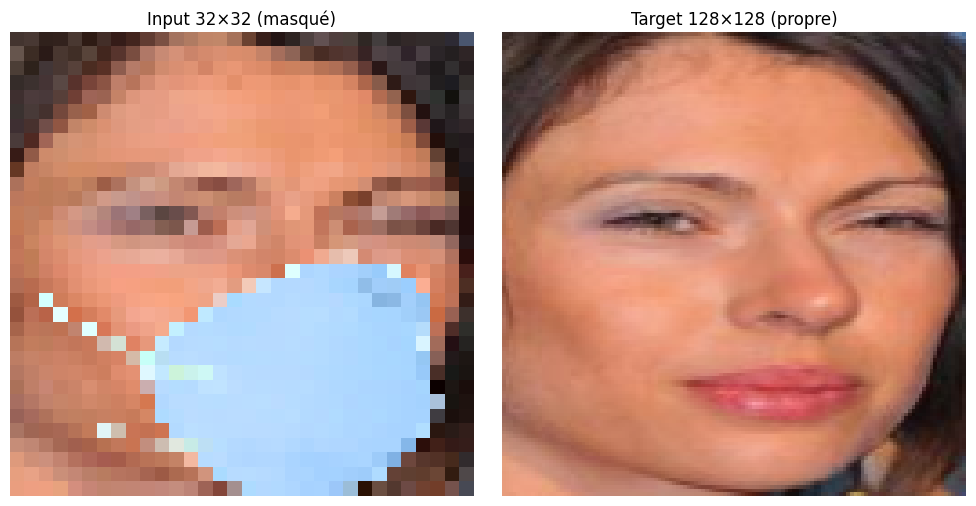


✅ Test réussi !

📊 RÉSUMÉ SETUP
✅ GPU : Activé
✅ PyTorch : 2.10.0+cu128
✅ Dataset : 19742 paires train
✅ Packages : opencv, lpips, timm, torchmetrics

🎯 Prêt pour l'implémentation !


In [3]:
"""
SETUP ENVIRONNEMENT - Vérifications et installations
"""

print("="*60)
print("SETUP ENVIRONNEMENT KAGGLE")
print("="*60)

# ============================================
# 1. VÉRIFIER GPU
# ============================================
print("\n🔍 Vérification GPU...")
import torch

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA disponible : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA version : {torch.version.cuda}")
    print(f"GPU name : {torch.cuda.get_device_name(0)}")
    print(f"GPU memory : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print("✅ GPU activé !")
else:
    print("❌ GPU non disponible")
    print("→ Aller dans Settings → Accelerator → GPU P100")

# ============================================
# 2. INSTALLER PACKAGES
# ============================================
print("\n📦 Installation des packages...")

!pip install -q opencv-python-headless
!pip install -q lpips  # Pour métrique perceptuelle
!pip install -q timm   # Pour certains backbones
!pip install -q torchmetrics  # Pour PSNR, SSIM

print("✅ Packages installés")

# ============================================
# 3. IMPORTS DE BASE
# ============================================
print("\n📚 Test des imports...")

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

import os
import glob
from pathlib import Path

print("✅ Tous les imports fonctionnent")

# ============================================
# 4. VÉRIFIER DATASET
# ============================================
print("\n📁 Vérification du dataset...")

DATASET_PATH = "/kaggle/working/dataset_processed"

train_input_path = f"{DATASET_PATH}/train/input_32"
train_target_path = f"{DATASET_PATH}/train/target_128"

num_train_input = len(glob.glob(f"{train_input_path}/*.png"))
num_train_target = len(glob.glob(f"{train_target_path}/*.png"))

print(f"Train inputs  : {num_train_input} images")
print(f"Train targets : {num_train_target} images")

if num_train_input == num_train_target and num_train_input > 0:
    print("✅ Dataset prêt !")
else:
    print("❌ Problème avec le dataset")

# ============================================
# 5. TEST CHARGEMENT IMAGE
# ============================================
print("\n🖼️  Test chargement d'une image...")

# Charger une paire
input_img = cv2.imread(f"{train_input_path}/000000.png")
target_img = cv2.imread(f"{train_target_path}/000000.png")

print(f"Input shape  : {input_img.shape}")
print(f"Target shape : {target_img.shape}")

# Visualiser
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(cv2.cvtColor(input_img, cv2.COLOR_BGR2RGB))
axes[0].set_title("Input 32×32 (masqué)")
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(target_img, cv2.COLOR_BGR2RGB))
axes[1].set_title("Target 128×128 (propre)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

print("\n✅ Test réussi !")

# ============================================
# 6. RÉSUMÉ
# ============================================
print("\n" + "="*60)
print("📊 RÉSUMÉ SETUP")
print("="*60)
print(f"✅ GPU : {'Activé' if torch.cuda.is_available() else 'Non activé'}")
print(f"✅ PyTorch : {torch.__version__}")
print(f"✅ Dataset : {num_train_input} paires train")
print(f"✅ Packages : opencv, lpips, timm, torchmetrics")
print("\n🎯 Prêt pour l'implémentation !")



**verification  que GPU est activé**

In [4]:
import torch

print("="*60)
print("VÉRIFICATION GPU")
print("="*60)

if torch.cuda.is_available():
    print("✅ GPU ACTIVÉ")
    print(f"GPU : {torch.cuda.get_device_name(0)}")
    print(f"Mémoire : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("❌ GPU NON ACTIVÉ")
    print("→ Settings → Accelerator → GPU P100")

VÉRIFICATION GPU
✅ GPU ACTIVÉ
GPU : Tesla T4
Mémoire : 15.64 GB


**DATALOADER PYTORCH - MEFSR-GANPour charger les paires 32×32 → 128×128**

In [5]:
%%writefile /kaggle/working/create_dataloader.py
"""
DATALOADER PYTORCH - MEFSR-GAN v2.2
Corrections :
  - Suppression flip vertical et rotations 90° (invalides pour visages)
  - Ajout ColorJitter léger
  - Flip horizontal uniquement (visages symétriques gauche/droite)
"""
import torch
from torch.utils.data import Dataset, DataLoader
import cv2
import numpy as np
from pathlib import Path
import glob
import random


class FaceSRDataset(Dataset):
    def __init__(self, data_root, train=True):
        self.data_root = Path(data_root)
        self.train = train
        self.input_files  = sorted(glob.glob(str(self.data_root / "input_32"   / "*.png")))
        self.target_files = sorted(glob.glob(str(self.data_root / "target_128" / "*.png")))
        assert len(self.input_files) == len(self.target_files), \
            f"Mismatch: {len(self.input_files)} inputs vs {len(self.target_files)} targets"
        print(f"[Dataset] {'Train' if train else 'Val/Test'} — {len(self.input_files)} paires chargées")

    def __len__(self):
        return len(self.input_files)

    def _augment(self, inp, tgt):
        """
        Augmentation adaptée aux visages.

        GARDÉ :
          - Flip horizontal (p=0.5) → visage miroir, réaliste
          - Brightness jitter très léger (±10%) → variation d'éclairage
          - Contrast jitter très léger (±8%) → variation de contraste

        SUPPRIMÉ (causaient de l'overfitting inutile) :
          - Flip vertical → visage à l'envers, n'existe pas dans le test set
          - Rotations 90°/180°/270° → visages couchés, n'existent pas dans le test set
        """

        # 1. Flip horizontal uniquement
        if random.random() > 0.5:
            inp = torch.flip(inp, dims=[2])
            tgt = torch.flip(tgt, dims=[2])

        # 2. Brightness jitter (même facteur sur input et target)
        if random.random() > 0.5:
            factor = random.uniform(0.90, 1.10)
            inp = torch.clamp(inp * factor, 0.0, 255.0)
            tgt = torch.clamp(tgt * factor, 0.0, 255.0)

        # 3. Contrast jitter léger
        if random.random() > 0.6:
            mean_inp = inp.mean()
            mean_tgt = tgt.mean()
            factor = random.uniform(0.92, 1.08)
            inp = torch.clamp((inp - mean_inp) * factor + mean_inp, 0.0, 255.0)
            tgt = torch.clamp((tgt - mean_tgt) * factor + mean_tgt, 0.0, 255.0)

        return inp, tgt

    def __getitem__(self, idx):
        input_img  = cv2.imread(self.input_files[idx])
        target_img = cv2.imread(self.target_files[idx])

        input_img  = cv2.cvtColor(input_img,  cv2.COLOR_BGR2RGB)
        target_img = cv2.cvtColor(target_img, cv2.COLOR_BGR2RGB)

        # Valeurs en [0, 255] float32 — c'est ce que le prof demandait
        input_img  = input_img.astype(np.float32)
        target_img = target_img.astype(np.float32)

        input_tensor  = torch.from_numpy(input_img).permute(2, 0, 1)   # [3, 32, 32]
        target_tensor = torch.from_numpy(target_img).permute(2, 0, 1)  # [3, 128, 128]

        if self.train:
            input_tensor, target_tensor = self._augment(input_tensor, target_tensor)

        return input_tensor, target_tensor


def create_dataloaders(dataset_root, batch_size=16, num_workers=2):
    train_root = Path(dataset_root) / "train"
    val_root   = Path(dataset_root) / "val"
    test_root  = Path(dataset_root) / "test"

    train_dataset = FaceSRDataset(train_root, train=True)
    val_dataset   = FaceSRDataset(val_root,   train=False)
    test_dataset  = FaceSRDataset(test_root,  train=False)

    train_loader = DataLoader(train_dataset, batch_size=batch_size,
                              shuffle=True,  num_workers=num_workers,
                              pin_memory=True, drop_last=True)
    val_loader   = DataLoader(val_dataset,   batch_size=batch_size,
                              shuffle=False, num_workers=num_workers,
                              pin_memory=True)
    test_loader  = DataLoader(test_dataset,  batch_size=batch_size,
                              shuffle=False, num_workers=num_workers,
                              pin_memory=True)

    print(f"\n[DataLoader] Train={len(train_dataset)} | Val={len(val_dataset)} | Test={len(test_dataset)}")
    return train_loader, val_loader, test_loader

Writing /kaggle/working/create_dataloader.py


1. **MODULE 1 : MASK REMOVAL**

In [6]:
%%writefile /kaggle/working/module1_mask_removal.py
"""
MODULE 1 : MASK REMOVAL
Inspiré de JDSR-GAN (2023)
IDENTIQUE pour toutes les versions

Input : [B, 3, 32, 32] (visage masqué LR)
Output : [B, 64, 32, 32] (features débruitées)
"""

import torch
import torch.nn as nn
import torch.nn.functional as F


class ResidualBlock(nn.Module):
    """Bloc résiduel de base avec skip connection"""
    def __init__(self, channels):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(channels)
    
    def forward(self, x):
        residual = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out += residual  # Skip connection
        out = self.relu(out)
        return out


class MaskRemovalModule(nn.Module):
    """
    Module de débruitage pour enlever le masque facial
    """
    
    def __init__(self, in_channels=3, out_channels=64, num_residual_blocks=4):
        super(MaskRemovalModule, self).__init__()
        
        # Encoder
        self.initial_conv = nn.Sequential(
            nn.Conv2d(in_channels, 64, kernel_size=7, padding=3),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )
        
        # Résidual blocks
        self.residual_blocks = nn.ModuleList([
            ResidualBlock(64) for _ in range(num_residual_blocks)
        ])
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    
    def forward(self, x):
        features = self.initial_conv(x)
        for res_block in self.residual_blocks:
            features = res_block(features)
        features = self.decoder(features)
        return features

Writing /kaggle/working/module1_mask_removal.py


**2. MODULE 2 : EDGE FUSION + attention**

In [7]:
%%writefile /kaggle/working/module2_edge_fusion.py
"""
MODULE 2 : EDGE FUSION AVEC ATTENTION
Inspiré de Cheng EFBPGAN (2024)

Input : [B, 64, 32, 32] features + [B, 1, 32, 32] edges
Output : [B, 64, 32, 32] features enrichies
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
import cv2
import numpy as np


# ============================================
# EXTRACTION EDGES (CANNY)
# ============================================
def extract_edges_canny(images, low_threshold=50, high_threshold=150):
    """
    Extrait les contours via l'algorithme de Canny
    """
    batch_size, _, H, W = images.shape
    device = images.device
    
    edges_batch = []
    
    for i in range(batch_size):
        img = images[i].cpu().permute(1, 2, 0).numpy()
        img = (img * 255).astype(np.uint8)
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        edges = cv2.Canny(gray, low_threshold, high_threshold)
        edges = edges.astype(np.float32) / 255.0
        edges_batch.append(edges)
    
    edges_batch = np.stack(edges_batch, axis=0)
    edges_tensor = torch.from_numpy(edges_batch).unsqueeze(1)
    
    return edges_tensor.to(device)


# ============================================
# ATTENTION MODULES
# ============================================
class ChannelAttention(nn.Module):
    """Channel Attention Module"""
    def __init__(self, channels, reduction=16):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        
        self.fc = nn.Sequential(
            nn.Conv2d(channels, channels // reduction, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels // reduction, channels, 1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        avg_out = self.fc(self.avg_pool(x))
        max_out = self.fc(self.max_pool(x))
        out = avg_out + max_out
        return self.sigmoid(out)


class SpatialAttention(nn.Module):
    """Spatial Attention Module"""
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        x = torch.cat([avg_out, max_out], dim=1)
        x = self.conv(x)
        return self.sigmoid(x)


class EdgeFusionAttention(nn.Module):
    """
    Version 2.0 : Fusion avec Attention (Channel + Spatial)
    """
    
    def __init__(self, feature_channels=64):
        super(EdgeFusionAttention, self).__init__()
        
        # Attention modules
        self.channel_attn = ChannelAttention(feature_channels)
        self.spatial_attn = SpatialAttention()
        
        # Fusion finale
        self.fusion = nn.Sequential(
            nn.Conv2d(feature_channels + 1, feature_channels, 3, padding=1),
            nn.BatchNorm2d(feature_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(feature_channels, feature_channels, 3, padding=1),
            nn.BatchNorm2d(feature_channels),
            nn.ReLU(inplace=True)
        )
    
    def forward(self, features, edges):
        """
        Args:
            features : [B, 64, 32, 32] features du Module 1
            edges : [B, 1, 32, 32] edges extraits par Canny
        
        Returns:
            fused : [B, 64, 32, 32] features enrichies avec attention
        """
        # Channel Attention sur features
        ca_weight = self.channel_attn(features)  # [B, 64, 1, 1]
        features_ca = features * ca_weight  # [B, 64, 32, 32]
        
        # Spatial Attention guidée par edges
        sa_weight = self.spatial_attn(edges)  # [B, 1, 32, 32]
        features_sa = features_ca * sa_weight  # [B, 64, 32, 32]
        
        # Concat avec edges
        combined = torch.cat([features_sa, edges], dim=1)  # [B, 65, 32, 32]
        
        # Fusion
        fused = self.fusion(combined)  # [B, 64, 32, 32]
        
        return fused

Writing /kaggle/working/module2_edge_fusion.py


3. **MODULE 3 : SR NETWORK AVEC ESRGAN**

In [8]:
%%writefile /kaggle/working/module3_sr_network.py
"""
MODULE 3 : SR NETWORK AVEC ESRGAN
Architecture RRDB (Residual in Residual Dense Block)

Input : [B, 64, 32, 32]
Output : [B, 3, 128, 128] (facteur ×4)
"""

import torch
import torch.nn as nn
import torch.nn.functional as F


# ============================================
# UPSAMPLING BLOCK
# ============================================
class UpsampleBlock(nn.Module):
    """Upsampling block (×2) avec PixelShuffle"""
    def __init__(self, in_channels, scale_factor=2):
        super(UpsampleBlock, self).__init__()
        self.conv = nn.Conv2d(in_channels, in_channels * (scale_factor ** 2), 3, padding=1)
        self.pixel_shuffle = nn.PixelShuffle(scale_factor)
        self.prelu = nn.PReLU()
    
    def forward(self, x):
        x = self.conv(x)
        x = self.pixel_shuffle(x)
        x = self.prelu(x)
        return x


# ============================================
# ESRGAN RRDB BLOCKS
# ============================================
class DenseBlock(nn.Module):
    """Dense block pour RRDB"""
    def __init__(self, channels, growth_channels=32):
        super(DenseBlock, self).__init__()
        self.conv1 = nn.Conv2d(channels, growth_channels, 3, padding=1)
        self.conv2 = nn.Conv2d(channels + growth_channels, growth_channels, 3, padding=1)
        self.conv3 = nn.Conv2d(channels + 2*growth_channels, growth_channels, 3, padding=1)
        self.conv4 = nn.Conv2d(channels + 3*growth_channels, growth_channels, 3, padding=1)
        self.conv5 = nn.Conv2d(channels + 4*growth_channels, channels, 3, padding=1)
        self.lrelu = nn.LeakyReLU(0.2, inplace=True)
        self.beta = 0.2  # Résidual scaling
    
    def forward(self, x):
        x1 = self.lrelu(self.conv1(x))
        x2 = self.lrelu(self.conv2(torch.cat([x, x1], dim=1)))
        x3 = self.lrelu(self.conv3(torch.cat([x, x1, x2], dim=1)))
        x4 = self.lrelu(self.conv4(torch.cat([x, x1, x2, x3], dim=1)))
        x5 = self.conv5(torch.cat([x, x1, x2, x3, x4], dim=1))
        return x5 * self.beta + x


class RRDB(nn.Module):
    """Residual in Residual Dense Block"""
    def __init__(self, channels, growth_channels=32):
        super(RRDB, self).__init__()
        self.dense1 = DenseBlock(channels, growth_channels)
        self.dense2 = DenseBlock(channels, growth_channels)
        self.dense3 = DenseBlock(channels, growth_channels)
        self.beta = 0.2
    
    def forward(self, x):
        out = self.dense1(x)
        out = self.dense2(out)
        out = self.dense3(out)
        return out * self.beta + x


class SRNetworkESRGAN(nn.Module):
    """
    Version 2.0 : SR Network avec RRDB (ESRGAN)
    Plus puissant que ResNet simple
    """
    
    def __init__(self, in_channels=64, out_channels=3, num_rrdb_blocks=12):
        super(SRNetworkESRGAN, self).__init__()
        
        # Initial conv
        self.conv_first = nn.Conv2d(in_channels, 64, 3, padding=1)
        
        # RRDB blocks
        self.rrdb_blocks = nn.ModuleList([
            RRDB(64, growth_channels=32) for _ in range(num_rrdb_blocks)
        ])
        
        # Conv après RRDB
        self.conv_body = nn.Conv2d(64, 64, 3, padding=1)
        
        # Upsampling ×4 (2 blocs ×2)
        self.upsample1 = UpsampleBlock(64, scale_factor=2)  # 32 → 64
        self.upsample2 = UpsampleBlock(64, scale_factor=2)  # 64 → 128
        
        # Conv finale
        self.conv_hr = nn.Conv2d(64, 64, 3, padding=1)
        self.lrelu = nn.LeakyReLU(0.2, inplace=True)
        self.conv_last = nn.Conv2d(64, out_channels, 3, padding=1)
    
    def forward(self, x):
        """
        Args:
            x : [B, 64, 32, 32] features enrichies
        
        Returns:
            out : [B, 3, 128, 128] image HR
        """
        feat = self.conv_first(x)
        trunk = feat
        
        # RRDB processing
        for block in self.rrdb_blocks:
            trunk = block(trunk)
        
        trunk = self.conv_body(trunk)
        feat = feat + trunk  # Long skip connection
        
        # Upsampling
        feat = self.upsample1(feat)  # [B, 64, 64, 64]
        feat = self.upsample2(feat)  # [B, 64, 128, 128]
        
        # Output RGB
        out = self.conv_hr(feat)
        out = self.lrelu(out)
        out = self.conv_last(out)  # [B, 3, 128, 128]
        
        return out

Writing /kaggle/working/module3_sr_network.py


**4. MEFSR-GAN VERSION**

In [9]:
%%writefile /kaggle/working/mefsr_gan_v2.py
"""
MEFSR-GAN VERSION 2.0
Architecture avec attention et ESRGAN

INPUT : [B, 3, 32, 32] visage masqué LR
OUTPUT : [B, 3, 128, 128] visage propre HR

Modules :
1. Mask Removal (identique à v1)
2. Edge Fusion avec Attention (Channel + Spatial)
3. SR Network ESRGAN (RRDB)
"""

import torch
import torch.nn as nn
import torch.nn.functional as F

# Import des modules
import sys
sys.path.append('/kaggle/working/')

from module1_mask_removal import MaskRemovalModule
from module2_edge_fusion import EdgeFusionAttention, extract_edges_canny
from module3_sr_network import SRNetworkESRGAN


class MEFSR_GAN_v2(nn.Module):
    """
    MEFSR-GAN Version 2.0
    - Fusion avec attention (channel + spatial)
    - Super-résolution ESRGAN (RRDB)
    """
    
    def __init__(self, num_mask_blocks=4, num_rrdb_blocks=8):
        super(MEFSR_GAN_v2, self).__init__()
        
        # Module 1 : Mask Removal (identique)
        self.mask_removal = MaskRemovalModule(
            in_channels=3,
            out_channels=64,
            num_residual_blocks=num_mask_blocks
        )
        
        # Module 2 : Edge Fusion avec Attention
        self.edge_fusion = EdgeFusionAttention(
            feature_channels=64
        )
        
        # Module 3 : SR Network ESRGAN
        self.sr_network = SRNetworkESRGAN(
            in_channels=64,
            out_channels=3,
            num_rrdb_blocks=num_rrdb_blocks
        )
    
    def forward(self, x):
        """
        Forward pass complet
        
        Args:
            x : [B, 3, 32, 32] visage masqué LR
        
        Returns:
            output : [B, 3, 128, 128] visage propre HR
        """
        # Module 1 : Enlever masque
        features = self.mask_removal(x)  # [B, 64, 32, 32]
        
        # Module 2a : Extraire edges
        with torch.no_grad():
            edges = extract_edges_canny(x)  # [B, 1, 32, 32]
        
        # Module 2b : Fusion features + edges avec attention
        fused_features = self.edge_fusion(features, edges)  # [B, 64, 32, 32]
        
        # Module 3 : Super-résolution ESRGAN
        output = self.sr_network(fused_features)  # [B, 3, 128, 128]
        
        return output
    
    def get_features(self, x):
        """
        Récupérer les features intermédiaires (utile pour visualisation)
        """
        features = self.mask_removal(x)
        edges = extract_edges_canny(x)
        fused = self.edge_fusion(features, edges)
        return {
            'mask_removed_features': features,
            'edges': edges,
            'fused_features': fused
        }


# ============================================
# TEST DE L'ARCHITECTURE COMPLÈTE
# ============================================
if __name__ == "__main__":
    print("="*60)
    print("TEST ARCHITECTURE COMPLÈTE : MEFSR-GAN v2.0")
    print("="*60)
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"\nDevice : {device}")
    
    # Créer le modèle
    model = MEFSR_GAN_v2(num_mask_blocks=4, num_rrdb_blocks=8).to(device)
    
    # Compter paramètres
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\nNombre total de paramètres : {total_params:,}")
    
    # Détail par module
    module1_params = sum(p.numel() for p in model.mask_removal.parameters())
    module2_params = sum(p.numel() for p in model.edge_fusion.parameters())
    module3_params = sum(p.numel() for p in model.sr_network.parameters())
    
    print(f"\nDétail :")
    print(f"  Module 1 (Mask Removal) : {module1_params:,}")
    print(f"  Module 2 (Edge Fusion)  : {module2_params:,}")
    print(f"  Module 3 (SR Network)   : {module3_params:,}")
    
    # Test forward pass
    print(f"\n{'='*60}")
    print("TEST FORWARD PASS")
    print("="*60)
    
    batch_size = 4
    x = torch.randn(batch_size, 3, 32, 32).to(device)
    
    print(f"\nInput shape : {x.shape}")
    
    with torch.no_grad():
        output = model(x)
    
    print(f"Output shape : {output.shape}")
    
    # Vérifier dimensions
    assert output.shape == (batch_size, 3, 128, 128), "Dimensions incorrectes !"
    
    print("\n✅ Architecture complète fonctionne !")
    
    # Vérifier range de sortie
    print(f"\nOutput range : [{output.min():.3f}, {output.max():.3f}]")
    
    # Mémoire GPU
    if torch.cuda.is_available():
        memory = torch.cuda.memory_allocated(device) / 1e9
        print(f"GPU memory used : {memory:.2f} GB")
    
    # Test avec DataLoader (si disponible)
    print(f"\n{'='*60}")
    print("TEST AVEC DATALOADER (optionnel)")
    print("="*60)
    
    try:
        # Essayer de charger le DataLoader
        import sys
        sys.path.append('/kaggle/working')
        from create_dataloader import create_dataloaders
        
        train_loader, _, _ = create_dataloaders(
            "/kaggle/working/dataset_processed",
            batch_size=4
        )
        
        # Tester sur un vrai batch
        inputs, targets = next(iter(train_loader))
        inputs = inputs.to(device)
        targets = targets.to(device)
        
        print(f"\nReal batch :")
        print(f"  Inputs : {inputs.shape}")
        print(f"  Targets : {targets.shape}")
        
        with torch.no_grad():
            outputs = model(inputs)
        
        print(f"  Outputs : {outputs.shape}")
        print("\n✅ Test avec vraies données : OK !")
        
    except Exception as e:
        print(f"\n⚠️  DataLoader non disponible : {e}")
        print("   (Normal si pas encore sur Kaggle)")
    
    print("\n" + "="*60)
    print("✅ MEFSR-GAN v2.0 PRÊT POUR L'ENTRAÎNEMENT !")
    print("="*60)

Writing /kaggle/working/mefsr_gan_v2.py


In [10]:
%%writefile /kaggle/working/module_losses.py


import torch
import torch.nn as nn
import torch.nn.functional as F
from pytorch_msssim import SSIM


# ============================================================
# PERCEPTUAL LOSS (VGG16) — CORRIGÉE
# ============================================================
class VGGPerceptualLoss(nn.Module):
    
    def __init__(self):
        super().__init__()
        from torchvision import models
        vgg = models.vgg16(pretrained=True).features[:16].eval()
        for p in vgg.parameters():
            p.requires_grad = False
        self.vgg = vgg

        # Normalisation ImageNet — register_buffer les met automatiquement
        # sur le bon device quand on fait .to(device)
        self.register_buffer(
            'mean',
            torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
        )
        self.register_buffer(
            'std',
            torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
        )

    def forward(self, sr, hr):
       
        # Étape 1 : [0,255] → [0,1]
        sr_01 = sr / 255.0
        hr_01 = hr / 255.0

        # Étape 2 : normalisation ImageNet
        sr_norm = (sr_01 - self.mean) / self.std
        hr_norm = (hr_01 - self.mean) / self.std

        # Étape 3 : features VGG → L1 loss
        return F.l1_loss(self.vgg(sr_norm), self.vgg(hr_norm))


# ============================================================
# IDENTITY LOSS (FaceNet) — INCHANGÉE (déjà correcte)
# ============================================================
class IdentityLoss(nn.Module):
   
    def __init__(self, device='cuda'):
        super().__init__()
        from facenet_pytorch import InceptionResnetV1
        self.facenet_device = torch.device('cpu')
        self.facenet = InceptionResnetV1(pretrained='vggface2').eval().to(self.facenet_device)
        for p in self.facenet.parameters():
            p.requires_grad = False
        self.main_device = torch.device(device) if isinstance(device, str) else device

    def forward(self, sr, hr):
        """
        sr, hr : tenseurs en [0, 255], shape [B, 3, H, W]
        """
        sr_resized = F.interpolate(sr, (160, 160), mode='bilinear', align_corners=False)
        hr_resized = F.interpolate(hr, (160, 160), mode='bilinear', align_corners=False)

        # [0, 255] → [0, 1] pour FaceNet
        sr_norm = sr_resized / 255.0
        hr_norm = hr_resized / 255.0

        sr_emb = self.facenet(sr_norm.to(self.facenet_device))
        hr_emb = self.facenet(hr_norm.to(self.facenet_device))

        sr_emb = F.normalize(sr_emb, p=2, dim=1)
        hr_emb = F.normalize(hr_emb, p=2, dim=1)

        loss = 1 - (sr_emb * hr_emb).sum(dim=1)
        return loss.mean().to(self.main_device)


# ============================================================
# SSIM LOSS — 
# ============================================================
class SSIMLoss(nn.Module):
    
    def __init__(self, channel=3):
        super().__init__()
        self.ssim = SSIM(data_range=255.0, size_average=True, channel=channel)

    def forward(self, img1, img2):
        """
        img1, img2 : tenseurs en [0, 255]
        Retourne 1 - SSIM (à minimiser)
        """
        return 1 - self.ssim(img1, img2)


# ============================================================
# PIXEL LOSS — 
# ============================================================
def pixel_loss_fn(pred, target, mae_fn, mse_fn):
    """
    Combinaison L1 (MAE) et L2 (MSE).
    Normalise en [0,1] avant calcul.
    pred, target : tenseurs en [0, 255]
    """
    pred_norm   = pred   / 255.0
    target_norm = target / 255.0
    return 0.8 * mae_fn(pred_norm, target_norm) + 0.2 * mse_fn(pred_norm, target_norm)

Writing /kaggle/working/module_losses.py


**losses** :  Pixel Loss, Perceptual, Identity  

**installation et test**

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models

class VGGPerceptualLoss(nn.Module):
    def __init__(self):
        super(VGGPerceptualLoss, self).__init__()
        # Charger VGG16 pré-entraîné et garder seulement les premières couches (jusqu'à la couche 16)
        vgg = models.vgg16(pretrained=True).features[:16].eval()
        for param in vgg.parameters():
            param.requires_grad = False
        self.vgg = vgg

    def forward(self, sr, hr):
        # sr et hr doivent être dans l'intervalle [0,1] ou normalisés comme pour VGG
        # VGG attend des images normalisées avec mean et std, mais on peut passer directement
        sr_feat = self.vgg(sr)
        hr_feat = self.vgg(hr)
        return F.l1_loss(sr_feat, hr_feat)

In [12]:
# Test rapide
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vgg_loss = VGGPerceptualLoss().to(device)
x = torch.randn(2, 3, 128, 128).to(device)
y = torch.randn(2, 3, 128, 128).to(device)
loss = vgg_loss(x, y)
print(f"Perceptual loss test: {loss.item()}")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 203MB/s]  


Perceptual loss test: 0.8814512491226196


In [13]:
!pip uninstall -y numpy scipy facenet-pytorch
!pip install numpy==1.26.4 scipy==1.13.1
!pip install facenet-pytorch

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
Found existing installation: scipy 1.16.3
Uninstalling scipy-1.16.3:
  Successfully uninstalled scipy-1.16.3
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 82.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.2/38.2 MB 50.4 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
kaggle-environments 1.27.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is in

In [14]:
import numpy, scipy, facenet_pytorch, torch
print("numpy:", numpy.__version__)
print("scipy:", scipy.__version__)
print("✅ facenet-pytorch OK")
# Test de conversion numpy
x = torch.randn(1, 3, 32, 32)
y = x.cpu().numpy()
print("✅ Conversion numpy réussie")

numpy: 2.0.2
scipy: 1.13.1
✅ facenet-pytorch OK
✅ Conversion numpy réussie


In [15]:
from facenet_pytorch import InceptionResnetV1
import torch.nn as nn
import torch.nn.functional as F

class IdentityLoss(nn.Module):
    def __init__(self, device='cuda'):
        super(IdentityLoss, self).__init__()
        from facenet_pytorch import InceptionResnetV1
        self.facenet_device = torch.device('cpu')  # ← FaceNet toujours sur CPU
        self.facenet = InceptionResnetV1(pretrained='vggface2').eval().to(self.facenet_device)
        for param in self.facenet.parameters():
            param.requires_grad = False
        self.main_device = torch.device(device) if isinstance(device, str) else device

    def forward(self, sr, hr):
        sr_resized = F.interpolate(sr, size=(160, 160), mode='bilinear', align_corners=False)
        hr_resized = F.interpolate(hr, size=(160, 160), mode='bilinear', align_corners=False)
        sr_resized = sr_resized.to(self.facenet_device)  # ← CPU pour FaceNet
        hr_resized = hr_resized.to(self.facenet_device)
        sr_emb = self.facenet(sr_resized)
        hr_emb = self.facenet(hr_resized)
        sr_emb = F.normalize(sr_emb, p=2, dim=1)
        hr_emb = F.normalize(hr_emb, p=2, dim=1)
        loss = 1 - (sr_emb * hr_emb).sum(dim=1)
        return loss.mean().to(self.main_device)  # ← retour sur GPU


In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
id_loss = IdentityLoss(device=device)
x = torch.randn(2, 3, 128, 128).to(device)
y = torch.randn(2, 3, 128, 128).to(device)
loss = id_loss(x, y)
print(f"Identity loss test: {loss.item()}")


  0%|          | 0.00/107M [00:00<?, ?B/s]

Identity loss test: 0.027068614959716797


In [17]:
!pip install pytorch-msssim

In [18]:
import torch.nn as nn
from pytorch_msssim import SSIM

class SSIMLoss(nn.Module):
    def __init__(self, channel=3):
        super(SSIMLoss, self).__init__()
        self.ssim = SSIM(data_range=255.0, size_average=True, channel=channel)
    def forward(self, img1, img2):
        return 1 - self.ssim(img1, img2)

In [19]:

!pip uninstall -y numpy
!pip install numpy==1.26.4

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
kaggle-environments 1.27.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0

In [20]:
import numpy
print("NumPy version :", numpy.__version__)

NumPy version : 2.0.2


**code d'entrainement**

In [21]:
import os
import shutil

# Chemin source : le fichier latest_checkpoint.pth dans le dataset
src_file = "/kaggle/input/datasets/fridamag/mefsr-checkpoints-v22/latest_checkpoint.pth"

# Dossier de destination (dans ton espace de travail)
dst_dir = "/kaggle/working/checkpoints_v2.2"
os.makedirs(dst_dir, exist_ok=True)
dst_file = os.path.join(dst_dir, "latest_checkpoint.pth")

# Copie
shutil.copy2(src_file, dst_file)
print(f"✅ Checkpoint copié vers {dst_file}")

# Vérification
if os.path.exists(dst_file):
    print(f"Taille : {os.path.getsize(dst_file)} octets")
else:
    print("❌ Échec de la copie.")

✅ Checkpoint copié vers /kaggle/working/checkpoints_v2.2/latest_checkpoint.pth
Taille : 79841702 octets


In [22]:
import os

print("Recherche de latest_checkpoint.pth...")
found = []
for root, dirs, files in os.walk("/kaggle/working"):
    if "latest_checkpoint.pth" in files:
        found.append(os.path.join(root, "latest_checkpoint.pth"))
for root, dirs, files in os.walk("/kaggle/input"):
    if "latest_checkpoint.pth" in files:
        found.append(os.path.join(root, "latest_checkpoint.pth"))

if found:
    print("Fichier(s) trouvé(s) :")
    for f in found:
        print(f"  - {f}")
else:
    print("Aucun fichier latest_checkpoint.pth trouvé.")

Recherche de latest_checkpoint.pth...
Fichier(s) trouvé(s) :
  - /kaggle/working/checkpoints_v2.2/latest_checkpoint.pth
  - /kaggle/input/datasets/fridamag/mefsr-checkpoints-v22/latest_checkpoint.pth
  - /kaggle/input/datasets/fridamag/mefsr-checkpoints-v22/results/kaggle/working/checkpoints_v2.2/latest_checkpoint.pth


In [23]:
import os
import shutil

# Supprimer l’ancien dossier local s’il existe
local_ckpt_dir = "/kaggle/working/checkpoints_v2.2"
if os.path.exists(local_ckpt_dir):
    shutil.rmtree(local_ckpt_dir)
    print("✅ Ancien dossier local supprimé")

# Copier les checkpoints depuis le dataset vers le working
src_dir = "/kaggle/input/datasets/fridamag/mefsr-checkpoints-v22"
dst_dir = local_ckpt_dir

shutil.copytree(src_dir, dst_dir)
print("✅ Checkpoints copiés depuis le dataset vers /kaggle/working/checkpoints_v2.2")

✅ Ancien dossier local supprimé
✅ Checkpoints copiés depuis le dataset vers /kaggle/working/checkpoints_v2.2


In [ ]:
import os
print("Contenu du dataset :", os.listdir("/kaggle/input/datasets/fridamag/mefsr-checkpoints-v22"))

In [26]:
import torch, os, time, json, subprocess, shutil, csv
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from create_dataloader import create_dataloaders
from module1_mask_removal import MaskRemovalModule
from module2_edge_fusion import EdgeFusionAttention, extract_edges_canny
from module3_sr_network import SRNetworkESRGAN
from module_losses import VGGPerceptualLoss, IdentityLoss, SSIMLoss, pixel_loss_fn

torch.backends.cudnn.enabled = False
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===================== CONFIGURATION =====================
VERSION_GAN      = "v2.2_GAN"
EPOCHS_GAN       = 30            # 30 époques (peut être augmenté)
LR_G             = 5e-5
LR_D             = 5e-5
LAMBDA_PIXEL     = 0.5
LAMBDA_PERCEP    = 0.4
LAMBDA_SSIM      = 0.4
LAMBDA_ID        = 0.2
LAMBDA_ADV       = 0.1
IDENTITY_EVERY   = 4
VALIDATION_EVERY = 5
GRAD_CLIP        = 1.0
BATCH_SIZE       = 16
DATASET_ROOT     = "/kaggle/working/dataset_processed"

KAGGLE_USERNAME = "fridamag"
DATASET_SLUG = f"{KAGGLE_USERNAME}/mefsr-checkpoints-v22-gan"   # Nouveau dataset
CHECKPOINT_DIR = f"/kaggle/working/checkpoints_{VERSION_GAN}"
VISUAL_DIR     = f"/kaggle/working/visuals_{VERSION_GAN}"
LOG_FILE       = f"/kaggle/working/log_{VERSION_GAN}.csv"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(VISUAL_DIR, exist_ok=True)

# ===================== FONCTIONS DE SYNCHRONISATION DATASET =====================
def sync_results_to_checkpoint_dir(epoch, include_zip=False, zip_path=None):
    vis_target = os.path.join(CHECKPOINT_DIR, "training_visuals")
    if os.path.exists(VISUAL_DIR):
        shutil.copytree(VISUAL_DIR, vis_target, dirs_exist_ok=True)
        print(f"   Visualisations copiées vers {vis_target}")
    if os.path.exists(LOG_FILE):
        shutil.copy(LOG_FILE, os.path.join(CHECKPOINT_DIR, "training_log.csv"))
    if include_zip and zip_path and os.path.exists(zip_path):
        shutil.copy(zip_path, os.path.join(CHECKPOINT_DIR, "results.zip"))
        print(f"   Zip final copié vers {CHECKPOINT_DIR}")

def push_checkpoint_to_dataset(checkpoint_dir, dataset_slug, epoch, include_zip=False, zip_path=None):
    try:
        sync_results_to_checkpoint_dir(epoch, include_zip, zip_path)
        meta_path = os.path.join(checkpoint_dir, "dataset-metadata.json")
        if not os.path.exists(meta_path):
            meta = {"title": f"MEFSR Checkpoints {VERSION_GAN}", "id": dataset_slug,
                    "licenses": [{"name": "CC0-1.0"}]}
            with open(meta_path, "w") as f:
                json.dump(meta, f)
        result = subprocess.run(
            ["kaggle", "datasets", "version", "-p", checkpoint_dir,
             "-m", f"auto-push GAN epoch {epoch}", "--dir-mode", "zip"],
            capture_output=True, text=True, timeout=180
        )
        if result.returncode != 0:
            print(f"   Dataset non trouvé, tentative de création...")
            result = subprocess.run(
                ["kaggle", "datasets", "create", "-p", checkpoint_dir,
                 "-r", "zip", "--dir-mode", "zip"],
                capture_output=True, text=True, timeout=180
            )
            if result.returncode == 0:
                print(f"   ✅ Dataset créé avec succès (epoch {epoch})")
            else:
                print(f"   ⚠️ Échec création : {result.stderr[:300]}")
        else:
            print(f"   ✅ Checkpoint mis à jour (epoch {epoch})")
    except subprocess.TimeoutExpired:
        print(f"   ⚠️ Timeout, checkpoint local toujours valide")
    except Exception as e:
        print(f"   ⚠️ Exception : {e}")

# ===================== ARCHITECTURES =====================
class MEFSR_GAN_v2(nn.Module):
    def __init__(self, num_mask_blocks=4, num_rrdb_blocks=8):
        super().__init__()
        self.mask_removal = MaskRemovalModule(3, 64, num_mask_blocks)
        self.edge_fusion  = EdgeFusionAttention(feature_channels=64)
        self.sr_network   = SRNetworkESRGAN(64, 3, num_rrdb_blocks)
    def forward(self, x):
        feat  = self.mask_removal(x)
        edges = extract_edges_canny(x)
        fused = self.edge_fusion(feat, edges)
        return self.sr_network(fused)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        def blk(ic, oc, bn=True):
            L = [nn.Conv2d(ic, oc, 4, 2, 1, bias=not bn)]
            if bn: L.append(nn.BatchNorm2d(oc))
            L.append(nn.LeakyReLU(0.2, inplace=True))
            return L
        self.net = nn.Sequential(
            *blk(3, 64, bn=False),
            *blk(64, 128),
            *blk(128, 256),
            *blk(256, 512),
            nn.Conv2d(512, 1, 4, 1, 1)
        )
    def forward(self, x):
        return self.net(x)

def lsgan_d(real, fake):
    return torch.mean((real - 1)**2) + torch.mean(fake**2)

def lsgan_g(fake):
    return torch.mean((fake - 1)**2)

# ===================== METRIQUES =====================
def psnr_np(img1, img2, data_range=255.0):
    mse = np.mean((img1 - img2) ** 2)
    return 20 * np.log10(data_range / np.sqrt(mse)) if mse != 0 else float('inf')

def ssim_np(img1, img2, data_range=255.0):
    img1 = img1.astype(np.float64)
    img2 = img2.astype(np.float64)
    mu1, mu2 = img1.mean(), img2.mean()
    sigma1_sq = ((img1 - mu1) ** 2).mean()
    sigma2_sq = ((img2 - mu2) ** 2).mean()
    sigma12   = ((img1 - mu1) * (img2 - mu2)).mean()
    c1 = (0.01 * data_range) ** 2
    c2 = (0.03 * data_range) ** 2
    return ((2*mu1*mu2 + c1) * (2*sigma12 + c2)) / ((mu1**2 + mu2**2 + c1) * (sigma1_sq + sigma2_sq + c2))

# ===================== DATALOADERS =====================
train_loader, val_loader, test_loader = create_dataloaders(DATASET_ROOT, batch_size=BATCH_SIZE, num_workers=2)

# ===================== CHARGER GENERATEUR (phase 1) =====================
generator = MEFSR_GAN_v2().to(DEVICE)
best_phase1_path = "/kaggle/input/mefsr-checkpoints-v22/checkpoints_v2.2/best_model.pth"
local_best_path  = "/kaggle/working/checkpoints_v2.2/best_model.pth"
if os.path.exists(best_phase1_path):
    generator.load_state_dict(torch.load(best_phase1_path, map_location=DEVICE))
    print(f"✅ Generator chargé depuis {best_phase1_path}")
elif os.path.exists(local_best_path):
    generator.load_state_dict(torch.load(local_best_path, map_location=DEVICE))
    print(f"✅ Generator chargé depuis {local_best_path}")
else:
    print("❌ best_model.pth introuvable – vérifiez les chemins!")

discriminator = Discriminator().to(DEVICE)
print(f"Generator   : {sum(p.numel() for p in generator.parameters()):,} param.")
print(f"Discriminator: {sum(p.numel() for p in discriminator.parameters()):,} param.")

# ===================== LOSSES & OPTIM =====================
mae_loss = nn.L1Loss()
mse_loss = nn.MSELoss()
perceptual_loss = VGGPerceptualLoss().to(DEVICE)
identity_loss_fn = IdentityLoss(device=DEVICE)
ssim_loss_fn = SSIMLoss(channel=3).to(DEVICE)

opt_g = torch.optim.Adam(generator.parameters(), lr=LR_G, betas=(0.9, 0.999))
opt_d = torch.optim.Adam(discriminator.parameters(), lr=LR_D, betas=(0.9, 0.999))
sch_g = torch.optim.lr_scheduler.ReduceLROnPlateau(opt_g, 'min', factor=0.5, patience=5, min_lr=1e-6)

# ===================== LOG CSV =====================
with open(LOG_FILE, 'w', newline='') as f:
    csv.writer(f).writerow(['epoch','loss_g','loss_d','loss_adv','val_loss','gap','lr_g'])

# ===================== VALIDATION BATCH FIXE =====================
val_batch_fixed = None
for inp, tgt in val_loader:
    val_batch_fixed = (inp[:4].to(DEVICE), tgt[:4].to(DEVICE))
    break

def visualize_results(epoch, generator, val_batch, save_dir):
    generator.eval()
    inputs, targets = val_batch
    with torch.no_grad():
        outputs = generator(inputs)
    fig, axes = plt.subplots(4, 3, figsize=(12,12))
    for i in range(4):
        in_up = torch.nn.functional.interpolate(inputs[i:i+1], size=(128,128), mode='bilinear')[0].cpu().permute(1,2,0).numpy() / 255.0
        out   = outputs[i].cpu().permute(1,2,0).numpy() / 255.0
        tgt   = targets[i].cpu().permute(1,2,0).numpy() / 255.0
        axes[i,0].imshow(np.clip(in_up,0,1)); axes[i,0].axis('off')
        axes[i,1].imshow(np.clip(out,0,1)); axes[i,1].axis('off')
        axes[i,2].imshow(np.clip(tgt,0,1)); axes[i,2].axis('off')
    plt.tight_layout()
    plt.savefig(f"{save_dir}/epoch_{epoch+1+50:03d}.png", dpi=150)
    plt.close(fig)

# ===================== TRACÉ COURBES =====================
def plot_gan_losses(csv_path, save_dir):
    import pandas as pd
    df = pd.read_csv(csv_path)
    for col in ['loss_g', 'loss_d', 'loss_adv', 'val_loss', 'gap']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    ax1.plot(df['epoch'], df['loss_g'], label='Loss_G (total)', marker='.', color='steelblue')
    ax1.plot(df['epoch'], df['loss_d'], label='Loss_D (discriminator)', marker='.', color='orange')
    ax1.plot(df['epoch'], df['loss_adv'], label='Adversarial Loss', marker='.', color='purple')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.set_title('GAN Losses (G, D, Adversarial)')
    ax1.legend(); ax1.grid(True, alpha=0.4)

    ax2.plot(df['epoch'], df['val_loss'], label='Validation loss', marker='.', color='green')
    ax2.plot(df['epoch'], df['gap'], label='Gap (val - train)', marker='.', color='red')
    ax2.axhline(0.02, linestyle='--', color='gray', label='overfitting threshold')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss / Gap')
    ax2.set_title('Validation & Overfitting')
    ax2.legend(); ax2.grid(True, alpha=0.4)

    plt.tight_layout()
    plot_path = os.path.join(save_dir, "gan_training_curves.png")
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    plt.close(fig)
    print(f"✅ Courbes GAN sauvegardées : {plot_path}")

# ===================== BOUCLE D'ENTRAÎNEMENT =====================
best_val_loss = float('inf')
print(f"\nPHASE 2 GAN — {VERSION_GAN}")
print("="*60)

for epoch in range(EPOCHS_GAN):
    generator.train()
    discriminator.train()
    tot_g = tot_d = tot_adv = 0.0
    loop = tqdm(train_loader, desc=f"GAN {epoch+1}/{EPOCHS_GAN}")
    
    for i, (inputs, targets) in enumerate(loop):
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        outputs = generator(inputs)
        
        # --- Discriminateur ---
        opt_d.zero_grad()
        r_logits = discriminator(targets)
        f_logits = discriminator(outputs.detach())
        loss_d = lsgan_d(r_logits, f_logits)
        loss_d.backward()
        torch.nn.utils.clip_grad_norm_(discriminator.parameters(), GRAD_CLIP)
        opt_d.step()
        
        # --- Générateur ---
        opt_g.zero_grad()
        f_logits_g = discriminator(outputs)
        loss_adv = lsgan_g(f_logits_g)
        loss_pixel = pixel_loss_fn(outputs, targets, mae_loss, mse_loss)
        loss_percep = perceptual_loss(outputs, targets)
        loss_ssim = ssim_loss_fn(outputs, targets)
        loss_id = (identity_loss_fn(outputs, targets) if i % IDENTITY_EVERY == 0 else torch.tensor(0.0, device=DEVICE))
        
        loss_g = (LAMBDA_PIXEL*loss_pixel + LAMBDA_PERCEP*loss_percep +
                  LAMBDA_SSIM*loss_ssim + LAMBDA_ID*loss_id + LAMBDA_ADV*loss_adv)
        loss_g.backward()
        torch.nn.utils.clip_grad_norm_(generator.parameters(), GRAD_CLIP)
        opt_g.step()
        
        tot_g   += loss_g.item()
        tot_d   += loss_d.item()
        tot_adv += loss_adv.item()
        loop.set_postfix(G=f"{loss_g.item():.3f}", D=f"{loss_d.item():.3f}")
    
    n = len(train_loader)
    avg_g = tot_g / n
    avg_d = tot_d / n
    avg_adv = tot_adv / n
    lr_now = opt_g.param_groups[0]['lr']
    
    print(f"\nGAN Epoch {epoch+1}/{EPOCHS_GAN} | Loss_G: {avg_g:.4f} | Loss_D: {avg_d:.4f} | Adv: {avg_adv:.4f} | LR: {lr_now:.2e}")
    
    # Validation
    val_loss_log = None
    if (epoch + 1) % VALIDATION_EVERY == 0:
        generator.eval()
        val_loss = 0.0
        with torch.no_grad():
            for inp, tgt in val_loader:
                inp, tgt = inp.to(DEVICE), tgt.to(DEVICE)
                out = generator(inp)
                l_p = pixel_loss_fn(out, tgt, mae_loss, mse_loss)
                l_c = perceptual_loss(out, tgt)
                l_s = ssim_loss_fn(out, tgt)
                l_i = identity_loss_fn(out, tgt)
                val_loss += (LAMBDA_PIXEL*l_p + LAMBDA_PERCEP*l_c + LAMBDA_SSIM*l_s + LAMBDA_ID*l_i).item()
        val_loss /= len(val_loader)
        val_loss_log = val_loss
        gap = val_loss - avg_g
        print(f"   Val Loss: {val_loss:.4f} | Gap: {gap:+.4f}")
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(generator.state_dict(), os.path.join(CHECKPOINT_DIR, "best_model_gan.pth"))
            print(f"   ✅ Best GAN model sauvegardé (val={val_loss:.4f})")
        
        visualize_results(epoch, generator, val_batch_fixed, VISUAL_DIR)
        sch_g.step(val_loss)
        
        # Bilan équilibre
        print(f"\n   ┌─ BILAN GAN (epoch {epoch+51})")
        print(f"   │  Loss_G : {avg_g:.4f}")
        print(f"   │  Loss_D : {avg_d:.4f}")
        if avg_d < 0.1:
            print(f"   │  ⚠️  Discriminateur trop fort → baisser LR_D")
        elif avg_d > 0.45:
            print(f"   │  ⚠️  Discriminateur trop faible → augmenter LR_D")
        else:
            print(f"   │  ✅ Équilibre G/D sain")
        print(f"   └{'─'*40}")
    
    # Checkpoint local et push dataset
    torch.save({
        'epoch': epoch + 50,
        'generator_state_dict': generator.state_dict(),
        'discriminator_state_dict': discriminator.state_dict(),
        'opt_g': opt_g.state_dict(),
        'opt_d': opt_d.state_dict(),
        'best_val_loss': best_val_loss,
        'version': VERSION_GAN,
    }, os.path.join(CHECKPOINT_DIR, "latest_gan_checkpoint.pth"))
    
    if (epoch + 1) % 10 == 0:
        push_checkpoint_to_dataset(CHECKPOINT_DIR, DATASET_SLUG, epoch+51, include_zip=False)
    
    with open(LOG_FILE, 'a', newline='') as f:
        csv.writer(f).writerow([epoch+51, avg_g, avg_d, avg_adv, val_loss_log or '', (val_loss_log - avg_g) if val_loss_log else '', lr_now])

# ===================== ÉVALUATION FINALE ET COURBES =====================
plot_gan_losses(LOG_FILE, VISUAL_DIR)

print("\nEvaluation finale sur le test set...")
generator.eval()
psnr_list, ssim_list = [], []
with torch.no_grad():
    for inp, tgt in test_loader:
        inp, tgt = inp.to(DEVICE), tgt.to(DEVICE)
        out = generator(inp)
        for i in range(inp.size(0)):
            out_np = np.clip(out[i].cpu().permute(1,2,0).numpy(), 0, 255)
            tgt_np = np.clip(tgt[i].cpu().permute(1,2,0).numpy(), 0, 255)
            psnr_list.append(psnr_np(tgt_np, out_np, data_range=255.0))
            ssim_list.append(ssim_np(tgt_np, out_np, data_range=255.0))
print(f"\n✅ RÉSULTATS FINAUX — {VERSION_GAN}")
print(f"   PSNR : {np.mean(psnr_list):.2f} dB")
print(f"   SSIM : {np.mean(ssim_list):.4f}")

metrics_file = f"/kaggle/working/metrics_{VERSION_GAN}.txt"
with open(metrics_file, "w") as f:
    f.write(f"Version          : {VERSION_GAN}\n")
    f.write(f"PSNR             : {np.mean(psnr_list):.2f} dB\n")
    f.write(f"SSIM             : {np.mean(ssim_list):.4f}\n")
    f.write(f"Best val loss    : {best_val_loss:.4f}\n")
    f.write(f"Lambdas          : Pixel={LAMBDA_PIXEL}, Percep={LAMBDA_PERCEP}, SSIM={LAMBDA_SSIM}, ID={LAMBDA_ID}, Adv={LAMBDA_ADV}\n")

# ===================== ARCHIVAGE ET PUSH FINAL =====================
print("\n📦 Création archive ZIP...")
items = [CHECKPOINT_DIR, VISUAL_DIR, LOG_FILE, metrics_file]
existing = [i for i in items if os.path.exists(i)]
if existing:
    from datetime import datetime
    archive = f"/kaggle/working/results_{VERSION_GAN}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.zip"
    os.system(f"zip -r {archive} " + " ".join(existing))
    print(f"Archive : {archive}")
    push_checkpoint_to_dataset(CHECKPOINT_DIR, DATASET_SLUG, 100, include_zip=True, zip_path=archive)
else:
    print("Aucun fichier à archiver.")

print("\n" + "="*60)
print("TOUT EST SAUVEGARDÉ DANS LE DATASET KAGGLE")
print(f"https://www.kaggle.com/{KAGGLE_USERNAME}/datasets")
print("="*60)

[Dataset] Train — 19742 paires chargées
[Dataset] Val/Test — 2467 paires chargées
[Dataset] Val/Test — 2469 paires chargées

[DataLoader] Train=19742 | Val=2467 | Test=2469
✅ Generator chargé depuis /kaggle/working/checkpoints_v2.2/best_model.pth
Generator   : 6,618,791 param.
Discriminator: 2,765,633 param.

PHASE 2 GAN — v2.2_GAN


GAN 1/30: 100%|██████████| 1233/1233 [23:56<00:00,  1.16s/it, D=0.421, G=0.509]



GAN Epoch 1/30 | Loss_G: 0.4855 | Loss_D: 0.4681 | Adv: 0.3357 | LR: 5.00e-05


GAN 2/30: 100%|██████████| 1233/1233 [23:48<00:00,  1.16s/it, D=0.409, G=0.523]



GAN Epoch 2/30 | Loss_G: 0.5026 | Loss_D: 0.4583 | Adv: 0.3543 | LR: 5.00e-05


...

   Val Loss: 0.5502 | Gap: +0.0212

   ┌─ BILAN GAN (epoch 65)
   │  Loss_G : 0.5291
   │  Loss_D : 0.4343
   │  ✅ Équilibre G/D sain
   └────────────────────────────────────────


GAN 16/30: 100%|██████████| 1233/1233 [24:07<00:00,  1.17s/it, D=0.421, G=0.568]



GAN Epoch 16/30 | Loss_G: 0.5291 | Loss_D: 0.4329 | Adv: 0.3933 | LR: 5.00e-05


GAN 17/30:  13%|█▎        | 158/1233 [03:06<21:12,  1.18s/it, D=0.410, G=0.529]


KeyboardInterrupt: 

In [35]:
import torch, os, time, json, subprocess, shutil, csv
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from create_dataloader import create_dataloaders
from module1_mask_removal import MaskRemovalModule
from module2_edge_fusion import EdgeFusionAttention, extract_edges_canny
from module3_sr_network import SRNetworkESRGAN
from module_losses import VGGPerceptualLoss, IdentityLoss, SSIMLoss, pixel_loss_fn

torch.backends.cudnn.enabled = False
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===================== CONFIGURATION =====================
VERSION_GAN      = "v2.2_GAN"
EPOCHS_GAN       = 25            # Total epochs GAN (epoch 51 → 80)

LR_G             = 5e-5
LR_D             = 5e-5

# ── LAMBDAS CORRIGÉS (fix identity drift) ──────────────
LAMBDA_PIXEL     = 0.5
LAMBDA_PERCEP    = 0.4
LAMBDA_SSIM      = 0.4
LAMBDA_ID        = 0.4   # ← était 0.2 — doublé pour ancrer l'identité
LAMBDA_ADV       = 0.05  # ← était 0.1 — réduit pour freiner le drift GAN
IDENTITY_EVERY   = 2     # ← était 4 — identity loss calculée 2x plus souvent
# ────────────────────────────────────────────────────────

VALIDATION_EVERY = 5
GRAD_CLIP        = 1.0
BATCH_SIZE       = 16
DATASET_ROOT     = "/kaggle/working/dataset_processed"

KAGGLE_USERNAME  = "fridamag"
DATASET_SLUG     = f"{KAGGLE_USERNAME}/mefsr-checkpoints-v22-gan"
CHECKPOINT_DIR   = f"/kaggle/working/checkpoints_{VERSION_GAN}"
VISUAL_DIR       = f"/kaggle/working/visuals_{VERSION_GAN}"
LOG_FILE         = f"/kaggle/working/log_{VERSION_GAN}.csv"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(VISUAL_DIR, exist_ok=True)

print(f"Device        : {DEVICE}")
print(f"LAMBDA_ID     : {LAMBDA_ID}  (was 0.2)")
print(f"LAMBDA_ADV    : {LAMBDA_ADV} (was 0.1)")
print(f"IDENTITY_EVERY: {IDENTITY_EVERY} (was 4)")


# ===================== FONCTIONS DATASET =====================
def sync_results_to_checkpoint_dir(epoch, include_zip=False, zip_path=None):
    vis_target = os.path.join(CHECKPOINT_DIR, "training_visuals")
    if os.path.exists(VISUAL_DIR):
        shutil.copytree(VISUAL_DIR, vis_target, dirs_exist_ok=True)
    if os.path.exists(LOG_FILE):
        shutil.copy(LOG_FILE, os.path.join(CHECKPOINT_DIR, "training_log.csv"))
    if include_zip and zip_path and os.path.exists(zip_path):
        shutil.copy(zip_path, os.path.join(CHECKPOINT_DIR, "results.zip"))

def push_checkpoint_to_dataset(checkpoint_dir, dataset_slug, epoch, include_zip=False, zip_path=None):
    try:
        sync_results_to_checkpoint_dir(epoch, include_zip, zip_path)
        meta_path = os.path.join(checkpoint_dir, "dataset-metadata.json")
        if not os.path.exists(meta_path):
            meta = {"title": f"MEFSR Checkpoints {VERSION_GAN}", "id": dataset_slug,
                    "licenses": [{"name": "CC0-1.0"}]}
            with open(meta_path, "w") as f:
                json.dump(meta, f)
        result = subprocess.run(
            ["kaggle", "datasets", "version", "-p", checkpoint_dir,
             "-m", f"auto-push GAN epoch {epoch}", "--dir-mode", "zip"],
            capture_output=True, text=True, timeout=180
        )
        if result.returncode != 0:
            result = subprocess.run(
                ["kaggle", "datasets", "create", "-p", checkpoint_dir,
                 "-r", "zip", "--dir-mode", "zip"],
                capture_output=True, text=True, timeout=180
            )
            if result.returncode == 0:
                print(f"   ✅ Dataset créé (epoch {epoch})")
            else:
                print(f"   ⚠️ Échec : {result.stderr[:200]}")
        else:
            print(f"   ✅ Checkpoint mis à jour (epoch {epoch})")
    except subprocess.TimeoutExpired:
        print(f"   ⚠️ Timeout — checkpoint local valide")
    except Exception as e:
        print(f"   ⚠️ Exception : {e}")


# ===================== ARCHITECTURES =====================
class MEFSR_GAN_v2(nn.Module):
    def __init__(self, num_mask_blocks=4, num_rrdb_blocks=8):
        super().__init__()
        self.mask_removal = MaskRemovalModule(3, 64, num_mask_blocks)
        self.edge_fusion  = EdgeFusionAttention(feature_channels=64)
        self.sr_network   = SRNetworkESRGAN(64, 3, num_rrdb_blocks)
    def forward(self, x):
        feat  = self.mask_removal(x)
        edges = extract_edges_canny(x)
        fused = self.edge_fusion(feat, edges)
        return self.sr_network(fused)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        def blk(ic, oc, bn=True):
            L = [nn.Conv2d(ic, oc, 4, 2, 1, bias=not bn)]
            if bn: L.append(nn.BatchNorm2d(oc))
            L.append(nn.LeakyReLU(0.2, inplace=True))
            return L
        self.net = nn.Sequential(
            *blk(3,   64,  bn=False),
            *blk(64,  128),
            *blk(128, 256),
            *blk(256, 512),
            nn.Conv2d(512, 1, 4, 1, 1)
        )
    def forward(self, x):
        return self.net(x)

def lsgan_d(real, fake):
    return torch.mean((real - 1)**2) + torch.mean(fake**2)

def lsgan_g(fake):
    return torch.mean((fake - 1)**2)


# ===================== MÉTRIQUES =====================
def psnr_np(img1, img2, data_range=255.0):
    mse = np.mean((img1 - img2) ** 2)
    return 20 * np.log10(data_range / np.sqrt(mse)) if mse != 0 else float('inf')

def ssim_np(img1, img2, data_range=255.0):
    img1 = img1.astype(np.float64)
    img2 = img2.astype(np.float64)
    mu1, mu2 = img1.mean(), img2.mean()
    s1  = ((img1 - mu1)**2).mean()
    s2  = ((img2 - mu2)**2).mean()
    s12 = ((img1 - mu1) * (img2 - mu2)).mean()
    c1  = (0.01 * data_range)**2
    c2  = (0.03 * data_range)**2
    return ((2*mu1*mu2 + c1)*(2*s12 + c2)) / ((mu1**2 + mu2**2 + c1)*(s1 + s2 + c2))


# ===================== DATALOADERS =====================
train_loader, val_loader, test_loader = create_dataloaders(
    DATASET_ROOT, batch_size=BATCH_SIZE, num_workers=2
)


# ===================== MODÈLES =====================
generator     = MEFSR_GAN_v2().to(DEVICE)
discriminator = Discriminator().to(DEVICE)
print(f"Generator     : {sum(p.numel() for p in generator.parameters()):,} param.")
print(f"Discriminator : {sum(p.numel() for p in discriminator.parameters()):,} param.")


# ===================== LOSSES =====================
mae_loss         = nn.L1Loss()
mse_loss         = nn.MSELoss()
perceptual_loss  = VGGPerceptualLoss().to(DEVICE)
identity_loss_fn = IdentityLoss(device=DEVICE)
ssim_loss_fn     = SSIMLoss(channel=3).to(DEVICE)


# ===================== OPTIMIZERS =====================
opt_g = torch.optim.Adam(generator.parameters(),     lr=LR_G, betas=(0.9, 0.999))
opt_d = torch.optim.Adam(discriminator.parameters(), lr=LR_D, betas=(0.9, 0.999))
sch_g = torch.optim.lr_scheduler.ReduceLROnPlateau(
    opt_g, 'min', factor=0.5, patience=5, min_lr=1e-6
)


# ===================== REPRISE CHECKPOINT =====================
# Priorité 1: checkpoint GAN local (session courante)
# Priorité 2: checkpoint GAN depuis dataset Kaggle input
# Priorité 3: best_model phase 1 (démarrage from scratch)

start_epoch   = 0
best_val_loss = float('inf')

LOCAL_GAN_CKPT = os.path.join(CHECKPOINT_DIR, "latest_gan_checkpoint.pth")
INPUT_GAN_CKPT = f"/kaggle/input/mefsr-checkpoints-v22-gan/checkpoints_{VERSION_GAN}/latest_gan_checkpoint.pth"
PHASE1_LOCAL   = "/kaggle/working/checkpoints_v2.2/best_model.pth"
PHASE1_INPUT   = "/kaggle/input/mefsr-checkpoints-v22/checkpoints_v2.2/best_model.pth"

if os.path.exists(LOCAL_GAN_CKPT):
    print(f"\nReprise depuis checkpoint GAN local...")
    ckpt = torch.load(LOCAL_GAN_CKPT, map_location=DEVICE)
    generator.load_state_dict(ckpt['generator_state_dict'])
    discriminator.load_state_dict(ckpt['discriminator_state_dict'])
    opt_g.load_state_dict(ckpt['opt_g'])
    opt_d.load_state_dict(ckpt['opt_d'])
    start_epoch   = ckpt['epoch'] - 50 + 1   # Convertit epoch global → epoch GAN local
    best_val_loss = ckpt['best_val_loss']
    print(f"   ✅ Repris à epoch global {ckpt['epoch']} → GAN epoch {start_epoch}/{EPOCHS_GAN}")
    print(f"   Best val loss : {best_val_loss:.4f}")
    print(f"   Nouveaux lambdas actifs : ID={LAMBDA_ID}, ADV={LAMBDA_ADV}, ID_EVERY={IDENTITY_EVERY}")

elif os.path.exists(INPUT_GAN_CKPT):
    print(f"\nReprise depuis dataset Kaggle input...")
    shutil.copy(INPUT_GAN_CKPT, LOCAL_GAN_CKPT)
    ckpt = torch.load(LOCAL_GAN_CKPT, map_location=DEVICE)
    generator.load_state_dict(ckpt['generator_state_dict'])
    discriminator.load_state_dict(ckpt['discriminator_state_dict'])
    opt_g.load_state_dict(ckpt['opt_g'])
    opt_d.load_state_dict(ckpt['opt_d'])
    start_epoch   = ckpt['epoch'] - 50 + 1
    best_val_loss = ckpt['best_val_loss']
    print(f"   ✅ Repris à epoch global {ckpt['epoch']} → GAN epoch {start_epoch}/{EPOCHS_GAN}")

elif os.path.exists(PHASE1_LOCAL):
    print(f"\nAucun checkpoint GAN — chargement best_model Phase 1 (local)...")
    generator.load_state_dict(torch.load(PHASE1_LOCAL, map_location=DEVICE))
    print(f"   ✅ Generator Phase 1 chargé")

elif os.path.exists(PHASE1_INPUT):
    print(f"\nAucun checkpoint GAN — chargement best_model Phase 1 (input)...")
    generator.load_state_dict(torch.load(PHASE1_INPUT, map_location=DEVICE))
    print(f"   ✅ Generator Phase 1 chargé")

else:
    print("❌ Aucun checkpoint trouvé — vérifier les chemins!")


# ===================== LOG CSV =====================
# Append si reprise, sinon créer
log_exists = os.path.exists(LOG_FILE) and start_epoch > 0
if not log_exists:
    with open(LOG_FILE, 'w', newline='') as f:
        csv.writer(f).writerow(['epoch','loss_g','loss_d','loss_adv','val_loss','gap','lr_g',
                                 'lambda_id','lambda_adv'])


# ===================== BATCH FIXE VISUALISATION =====================
val_batch_fixed = None
for inp, tgt in val_loader:
    val_batch_fixed = (inp[:4].to(DEVICE), tgt[:4].to(DEVICE))
    break

def visualize_results(epoch_global, generator, val_batch, save_dir):
    try:
        generator.eval()
        inputs, targets = val_batch
        with torch.no_grad():
            outputs = generator(inputs)
        fig, axes = plt.subplots(4, 3, figsize=(12, 12))
        fig.suptitle(f"MEFSR-GAN v2.2 — Epoch {epoch_global} (ID={LAMBDA_ID}, ADV={LAMBDA_ADV})",
                     fontsize=12)
        for i in range(4):
            in_up = torch.nn.functional.interpolate(
                inputs[i:i+1], size=(128, 128), mode='bilinear'
            )[0].cpu().permute(1, 2, 0).numpy() / 255.0
            out = outputs[i].cpu().permute(1, 2, 0).numpy() / 255.0
            tgt = targets[i].cpu().permute(1, 2, 0).numpy() / 255.0
            axes[i,0].imshow(np.clip(in_up, 0, 1)); axes[i,0].set_title("Input LR");  axes[i,0].axis('off')
            axes[i,1].imshow(np.clip(out,   0, 1)); axes[i,1].set_title("Output SR"); axes[i,1].axis('off')
            axes[i,2].imshow(np.clip(tgt,   0, 1)); axes[i,2].set_title("Target HR"); axes[i,2].axis('off')
        plt.tight_layout()
        plt.savefig(f"{save_dir}/epoch_{epoch_global:03d}.png", dpi=150, bbox_inches='tight')
        plt.close(fig)
        print(f"   Visualisation sauvegardée : epoch_{epoch_global:03d}.png")
    except Exception as e:
        print(f"   Erreur visualisation : {e}")
        plt.close('all')


# ===================== TRACÉ COURBES =====================
def plot_gan_losses(csv_path, save_dir):
    try:
        import pandas as pd
        df = pd.read_csv(csv_path)
        for col in ['loss_g', 'loss_d', 'loss_adv', 'val_loss', 'gap']:
            df[col] = pd.to_numeric(df[col], errors='coerce')

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        fig.suptitle("MEFSR-GAN v2.2 — Courbes d'entraînement", fontsize=13, fontweight='bold')

        # Plot 1: Losses G, D, Adv
        axes[0].plot(df['epoch'], df['loss_g'],   label='Loss_G',         color='steelblue', marker='.')
        axes[0].plot(df['epoch'], df['loss_d'],   label='Loss_D',         color='orange',    marker='.')
        axes[0].plot(df['epoch'], df['loss_adv'], label='Adversarial',    color='purple',    marker='.', linestyle='--')
        axes[0].set_title('GAN Losses'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
        axes[0].legend(); axes[0].grid(True, alpha=0.4)

        # Plot 2: Validation
        val_df = df.dropna(subset=['val_loss'])
        axes[1].plot(val_df['epoch'], val_df['val_loss'], label='Val loss', color='green', marker='o')
        axes[1].plot(df['epoch'],     df['loss_g'],       label='Train G',  color='steelblue', alpha=0.5)
        axes[1].set_title('Val vs Train'); axes[1].set_xlabel('Epoch')
        axes[1].legend(); axes[1].grid(True, alpha=0.4)

        # Plot 3: Gap overfitting
        gap_df = df.dropna(subset=['gap'])
        colors = ['red' if g > 0.07 else 'orange' if g > 0.04 else 'green' for g in gap_df['gap']]
        axes[2].bar(gap_df['epoch'], gap_df['gap'], color=colors, alpha=0.7)
        axes[2].axhline(0.04, linestyle='--', color='orange', label='Warning (0.04)')
        axes[2].axhline(0.07, linestyle='--', color='red',    label='Critical (0.07)')
        axes[2].set_title('Gap (Overfitting)'); axes[2].set_xlabel('Epoch')
        axes[2].legend(); axes[2].grid(True, alpha=0.4)

        plt.tight_layout()
        plot_path = os.path.join(save_dir, "gan_training_curves.png")
        plt.savefig(plot_path, dpi=150, bbox_inches='tight')
        plt.close(fig)
        print(f"✅ Courbes GAN sauvegardées : {plot_path}")
    except Exception as e:
        print(f"⚠️ Erreur tracé courbes : {e}")


# ===================== BOUCLE D'ENTRAÎNEMENT =====================
print(f"\nPHASE 2 GAN — {VERSION_GAN}")
print(f"Reprise à GAN epoch {start_epoch+1}/{EPOCHS_GAN} (global: {start_epoch+51})")
print("="*60)

for epoch in range(start_epoch, EPOCHS_GAN):
    epoch_global = epoch + 51   # Epoch numérotation globale (51–80)

    generator.train()
    discriminator.train()
    tot_g = tot_d = tot_adv = 0.0
    loop = tqdm(train_loader, desc=f"GAN {epoch+1}/{EPOCHS_GAN} [ep.{epoch_global}]")

    for i, (inputs, targets) in enumerate(loop):
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        outputs = generator(inputs)

        # ── Discriminateur ─────────────────────────────────
        opt_d.zero_grad()
        r_logits = discriminator(targets)
        f_logits = discriminator(outputs.detach())
        loss_d   = lsgan_d(r_logits, f_logits)
        loss_d.backward()
        torch.nn.utils.clip_grad_norm_(discriminator.parameters(), GRAD_CLIP)
        opt_d.step()

        # ── Générateur ─────────────────────────────────────
        opt_g.zero_grad()
        f_logits_g  = discriminator(outputs)
        loss_adv    = lsgan_g(f_logits_g)
        loss_pixel  = pixel_loss_fn(outputs, targets, mae_loss, mse_loss)
        loss_percep = perceptual_loss(outputs, targets)
        loss_ssim   = ssim_loss_fn(outputs, targets)

        # Identity loss calculée toutes les IDENTITY_EVERY iterations
        loss_id = (
            identity_loss_fn(outputs, targets)
            if i % IDENTITY_EVERY == 0
            else torch.tensor(0.0, device=DEVICE)
        )

        loss_g = (
            LAMBDA_PIXEL  * loss_pixel  +
            LAMBDA_PERCEP * loss_percep +
            LAMBDA_SSIM   * loss_ssim   +
            LAMBDA_ID     * loss_id     +   # ← 0.4 (renforcé)
            LAMBDA_ADV    * loss_adv        # ← 0.05 (réduit)
        )

        loss_g.backward()
        torch.nn.utils.clip_grad_norm_(generator.parameters(), GRAD_CLIP)
        opt_g.step()

        tot_g   += loss_g.item()
        tot_d   += loss_d.item()
        tot_adv += loss_adv.item()
        loop.set_postfix(G=f"{loss_g.item():.3f}", D=f"{loss_d.item():.3f}")

    n       = len(train_loader)
    avg_g   = tot_g   / n
    avg_d   = tot_d   / n
    avg_adv = tot_adv / n
    lr_now  = opt_g.param_groups[0]['lr']

    print(f"\nGAN Epoch {epoch+1}/{EPOCHS_GAN} [global {epoch_global}]"
          f" | Loss_G: {avg_g:.4f} | Loss_D: {avg_d:.4f}"
          f" | Adv: {avg_adv:.4f} | LR: {lr_now:.2e}")

    # ── Validation ─────────────────────────────────────────
    val_loss_log = None
    if (epoch + 1) % VALIDATION_EVERY == 0:
        generator.eval()
        val_loss = 0.0
        with torch.no_grad():
            for inp, tgt in val_loader:
                inp, tgt = inp.to(DEVICE), tgt.to(DEVICE)
                out = generator(inp)
                l_p = pixel_loss_fn(out, tgt, mae_loss, mse_loss)
                l_c = perceptual_loss(out, tgt)
                l_s = ssim_loss_fn(out, tgt)
                l_i = identity_loss_fn(out, tgt)
                val_loss += (LAMBDA_PIXEL*l_p + LAMBDA_PERCEP*l_c +
                             LAMBDA_SSIM*l_s  + LAMBDA_ID*l_i).item()
        val_loss    /= len(val_loader)
        val_loss_log = val_loss
        gap          = val_loss - avg_g

        print(f"   Val Loss: {val_loss:.4f} | Gap: {gap:+.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(generator.state_dict(),
                       os.path.join(CHECKPOINT_DIR, "best_model_gan.pth"))
            print(f"   ✅ Best GAN model sauvegardé (val={val_loss:.4f})")

        visualize_results(epoch_global, generator, val_batch_fixed, VISUAL_DIR)
        sch_g.step(val_loss)

        # Bilan équilibre G/D
        print(f"\n   ┌─ BILAN GAN (epoch global {epoch_global})")
        print(f"   │  Loss_G       : {avg_g:.4f}")
        print(f"   │  Loss_D       : {avg_d:.4f}")
        print(f"   │  Adv contrib  : {LAMBDA_ADV * avg_adv:.4f}  (λ={LAMBDA_ADV} × {avg_adv:.3f})")
        print(f"   │  ID  contrib  : {LAMBDA_ID * avg_g:.4f}  (λ={LAMBDA_ID})")
        if avg_d < 0.10:
            print(f"   │  ⚠️  D trop fort → baisser LR_D à 2e-5")
        elif avg_d > 0.48:
            print(f"   │  ⚠️  D trop faible → augmenter LR_D")
        else:
            print(f"   │  ✅ Équilibre G/D sain")
        if gap > 0.07:
            print(f"   │  ⚠️  Gap élevé ({gap:.3f}) → surveiller overfitting")
        else:
            print(f"   │  ✅ Gap OK ({gap:.3f})")
        print(f"   └{'─'*42}")

    # ── Checkpoint local ───────────────────────────────────
    torch.save({
        'epoch':                     epoch_global,
        'generator_state_dict':      generator.state_dict(),
        'discriminator_state_dict':  discriminator.state_dict(),
        'opt_g':                     opt_g.state_dict(),
        'opt_d':                     opt_d.state_dict(),
        'best_val_loss':             best_val_loss,
        'version':                   VERSION_GAN,
        'lambda_id':                 LAMBDA_ID,
        'lambda_adv':                LAMBDA_ADV,
    }, LOCAL_GAN_CKPT)

    # ── Push Kaggle toutes les 5 epochs ───────────────────
    if (epoch + 1) % 5 == 0:
        push_checkpoint_to_dataset(CHECKPOINT_DIR, DATASET_SLUG, epoch_global)

    # ── Log CSV ────────────────────────────────────────────
    with open(LOG_FILE, 'a', newline='') as f:
        csv.writer(f).writerow([
            epoch_global, avg_g, avg_d, avg_adv,
            val_loss_log or '',
            (val_loss_log - avg_g) if val_loss_log else '',
            lr_now, LAMBDA_ID, LAMBDA_ADV
        ])


# ===================== COURBES FINALES =====================
plot_gan_losses(LOG_FILE, VISUAL_DIR)


# ===================== ÉVALUATION FINALE TEST SET =====================
print("\nEvaluation finale sur le test set...")

# Charger le best model GAN
best_gan_path = os.path.join(CHECKPOINT_DIR, "best_model_gan.pth")
if os.path.exists(best_gan_path):
    generator.load_state_dict(torch.load(best_gan_path, map_location=DEVICE))
    print(f"✅ Best GAN model chargé pour évaluation finale")
else:
    print("⚠️ best_model_gan.pth non trouvé — utilisation du dernier état")

generator.eval()
psnr_list, ssim_list = [], []

with torch.no_grad():
    for inp, tgt in test_loader:
        inp, tgt = inp.to(DEVICE), tgt.to(DEVICE)
        out = generator(inp)
        for i in range(inp.size(0)):
            out_np = np.clip(out[i].cpu().permute(1, 2, 0).numpy(), 0, 255)
            tgt_np = np.clip(tgt[i].cpu().permute(1, 2, 0).numpy(), 0, 255)
            psnr_list.append(psnr_np(tgt_np, out_np))
            ssim_list.append(ssim_np(tgt_np, out_np))

psnr_mean = np.mean(psnr_list)
ssim_mean = np.mean(ssim_list)

print(f"\n{'='*60}")
print(f"RÉSULTATS FINAUX — {VERSION_GAN}")
print(f"{'='*60}")
print(f"   PSNR : {psnr_mean:.2f} dB")
print(f"   SSIM : {ssim_mean:.4f}")
print(f"   Best val loss : {best_val_loss:.4f}")
print(f"   Lambdas utilisés : ID={LAMBDA_ID}, ADV={LAMBDA_ADV}, ID_EVERY={IDENTITY_EVERY}")

metrics_file = f"/kaggle/working/metrics_{VERSION_GAN}.txt"
with open(metrics_file, "w") as f:
    f.write(f"Version          : {VERSION_GAN}\n")
    f.write(f"PSNR             : {psnr_mean:.2f} dB\n")
    f.write(f"SSIM             : {ssim_mean:.4f}\n")
    f.write(f"Best val loss    : {best_val_loss:.4f}\n")
    f.write(f"LAMBDA_PIXEL     : {LAMBDA_PIXEL}\n")
    f.write(f"LAMBDA_PERCEP    : {LAMBDA_PERCEP}\n")
    f.write(f"LAMBDA_SSIM      : {LAMBDA_SSIM}\n")
    f.write(f"LAMBDA_ID        : {LAMBDA_ID}  (correction drift: était 0.2)\n")
    f.write(f"LAMBDA_ADV       : {LAMBDA_ADV} (correction drift: était 0.1)\n")
    f.write(f"IDENTITY_EVERY   : {IDENTITY_EVERY} (correction drift: était 4)\n")
    f.write(f"Epochs GAN       : {EPOCHS_GAN} (global 51-80)\n")
    f.write(f"Reprise depuis   : epoch 65\n")


# ===================== ARCHIVAGE ET PUSH FINAL =====================
print("\nCréation archive ZIP finale...")
items    = [CHECKPOINT_DIR, VISUAL_DIR, LOG_FILE, metrics_file]
existing = [i for i in items if os.path.exists(i)]
if existing:
    from datetime import datetime
    archive = f"/kaggle/working/results_{VERSION_GAN}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.zip"
    os.system(f"zip -r {archive} " + " ".join(existing))
    print(f"Archive : {archive}")
    push_checkpoint_to_dataset(CHECKPOINT_DIR, DATASET_SLUG, 80, include_zip=True, zip_path=archive)

print(f"\n{'='*60}")
print("TOUT SAUVEGARDÉ SUR KAGGLE")
print(f"https://www.kaggle.com/{KAGGLE_USERNAME}/datasets")
print(f"{'='*60}")

Device        : cuda
LAMBDA_ID     : 0.4  (was 0.2)
LAMBDA_ADV    : 0.05 (was 0.1)
IDENTITY_EVERY: 2 (was 4)
[Dataset] Train — 19742 paires chargées
[Dataset] Val/Test — 2467 paires chargées
[Dataset] Val/Test — 2469 paires chargées

[DataLoader] Train=19742 | Val=2467 | Test=2469
Generator     : 6,618,791 param.
Discriminator : 2,765,633 param.


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



Reprise depuis checkpoint GAN local...
   ✅ Repris à epoch global 75 → GAN epoch 26/25
   Best val loss : 0.5322
   Nouveaux lambdas actifs : ID=0.4, ADV=0.05, ID_EVERY=2

PHASE 2 GAN — v2.2_GAN
Reprise à GAN epoch 27/25 (global: 77)
⚠️ Erreur tracé courbes : Error tokenizing data. C error: Expected 7 fields in line 18, saw 9


Evaluation finale sur le test set...
✅ Best GAN model chargé pour évaluation finale

RÉSULTATS FINAUX — v2.2_GAN
   PSNR : 23.46 dB
   SSIM : 0.9530
   Best val loss : 0.5322
   Lambdas utilisés : ID=0.4, ADV=0.05, ID_EVERY=2

Création archive ZIP finale...
  adding: kaggle/working/checkpoints_v2.2_GAN/ (stored 0%)
  adding: kaggle/working/checkpoints_v2.2_GAN/training_visuals/ (stored 0%)
  adding: kaggle/working/checkpoints_v2.2_GAN/training_visuals/epoch_065.png (deflated 5%)
  adding: kaggle/working/checkpoints_v2.2_GAN/training_visuals/epoch_075.png (deflated 0%)
  adding: kaggle/working/checkpoints_v2.2_GAN/training_visuals/epoch_055.png (deflated 5%)
  a